CELL VERSION: trigger_time_v24_revert_preselection_rock_2026-08-20
Reading exposures (trigger_time tree)...
    onbeam: POT read from events/onbeam/POT histogram = 2.216270e+19
    onbeam: Livetime read from events/onbeam/Livetime histogram = 4.839580e+05
    offbeam: POT read from events/offbeam/POT histogram = 0.000000e+00
    offbeam: Livetime read from events/offbeam/Livetime histogram = 5.078498e+06
    rock: POT read from events/rock/POT histogram = 1.706694e+19
    rock: Livetime read from events/rock/Livetime histogram = 2.017200e+05
    nominal: POT read from events/nominal/POT histogram = 7.785208e+20
    nominal: Livetime read from events/nominal/Livetime histogram = 1.501200e+06

Onbeam POT (raw, from file)                : 2.216270e+19
Onbeam POT (validated, histogram-integration): 2.361240e+19  (Moreno, NuMI POT Counting Closure Test, Apr 1 2025 -- used for ONBEAM_POT/mc_scale/rock_scale only; NOT applied to offbeam livetime, see comment above)
Offbeam livetime (raw, from

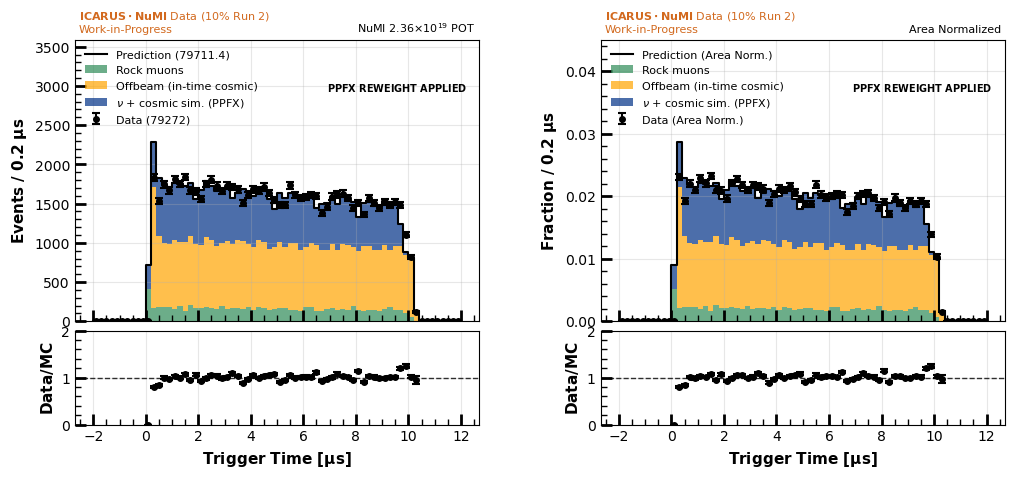


--- trigger_time [Rock included (Roy's approach: full FV-restricted rock sample, POT-scaled)] (POT-normalized | area-normalized, PPFX applied) ---
  rows loaded: mc 1501200  rock 46844 (0 if excluded)  onbeam 79272  offbeam 435919
  data               : 79272
  prediction         : 79711.4 +/- 128.2 (stat)
    nu+cosmic sim    : 29838.7
    rock muons       : 8331.5  (full FV-restricted rock sample, POT-scaled, no truth-matching filter -- Roy's approach, see header comment)
    offbeam (cosmic) : 41541.1
  data/MC            : 0.9945 +/- 0.0039
  folded into edge bins: underflow 0, overflow 0

  excluded as 'no usable event_trigger_within_gate' (<= -1e+10, i.e. the -DBL_MAX sentinel):
     nominal:  560484 / 1501200 rows (37.3%)  -- scaled weight excluded: 17777.1
        rock:   40822 /   46844 rows (87.1%)  -- scaled weight excluded: 56477.9
      onbeam:       0 /   79272 rows (0.0%)  -- scaled weight excluded: 0.0
     offbeam:       0 /  435919 rows (0.0%)  -- scaled weight exclu

In [2]:
# ============================================================================
# Trigger-time preselection plot (Howard Fig. 7/8 style), from the
# `trigger_time` tree in selection/toml/preselection.toml.
#
# `trigger_time` is a mode = "event" tree: one row per triggered event, not
# one row per reconstructed interaction like `preselection`. That is a real
# structural consequence of how selection/src/framework.cc dispatches branch
# construction (see the comment block in preselection.toml) -- not a
# simplification chosen here. A mode = "event" tree can only carry branches
# of type = "event" (framework.cc's Mode::Event block only recognizes that
# one type), so `true_pdg` / `true_neutrino_energy` (both type = "mctruth")
# are NOT available directly on this tree -- there is no way to compute the
# PPFX weight from `trigger_time` alone.
#
# PPFX weight, via a join to `preselection`:
#   Both `trigger_time` and `preselection` carry Run/Subrun/Evt columns, so
#   the per-event PPFX weight is obtained by building a
#   (Run, Subrun, Evt) -> (true_pdg, true_neutrino_energy) lookup from
#   `events/nominal/preselection` and merging it onto `trigger_time`. This
#   join is NOT complete: `preselection`'s cuts include `fiducial_cut` (a
#   reco-level, row-filtering cut -- only interactions reconstructed inside
#   the fiducial volume get a row there), while `trigger_time`'s only cuts
#   are the two event-level ones. So a `trigger_time` row for an event with
#   no fiducial-volume interaction (none reconstructed, or reconstructed
#   outside the FV) will not find a match. The match fraction is measured
#   and printed below rather than assumed; unmatched rows get PPFX weight
#   1.0 (the same fallback compute_ppfx already uses for non-numu/numubar
#   PDGs), which is reported explicitly so it isn't a silent bias.
#
# Rock muon treatment -- Roy's approach (NuMu_CC_Inclusive_Technote,
# Sec. 4.3/4.4): the rock sample is a separate MC production, scaled
# directly to the data exposure by POT ratio (same as our nominal MC/rock
# scaling), and shown as its own component in the trigger-time comparison
# (her Fig. 13b) without any truth-matching-based split. Background
# suppression is handled elsewhere in her selection chain via geometric/
# topological rejection cuts (fiducial-volume vertex requirement, rejecting
# tracks that enter from the detector boundary, CRT timing), not by
# filtering the rock sample itself with a truth-matching criterion. We
# follow the same approach here: the "rock included" case below uses the
# full rock/trigger_time sample restricted to fiducial-volume interactions
# (the FV requirement is the geometric cut, analogous to Roy's), with no
# additional true_category/n_true_nu-based filter on top. (An earlier
# version of this cell tried isolating "genuine" rock muons via
# true_category != 9, and a finer n_true_nu-based criterion on top of that;
# both were dropped in favor of matching Roy's simpler, cut-based treatment.)
#
# Rock is NOT PPFX-reweighted (standing instruction: rock muons are not beam
# neutrinos).
#
# Self-contained: re-imports and re-defines everything it needs.
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

print("CELL VERSION: trigger_time_v24_revert_preselection_rock_2026-08-20")

# ------------------------------------------------------------------ config --
DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/preselection.root")

FLUX_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "systematics/2025-04-08_out_450.37_7991.98_79512.66.root")

OUTPUT_DIR = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
              "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
              "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
              "ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/"
              "1muNp0pi_Nge1_uncontained/preselection")

ONBEAM_POT  = 2.36124e19
MC_SAMPLE   = "nominal"
TREE        = "trigger_time"
horn_current = 'fhc'

# ------------------------------------------------------------------ style ---
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

# ------------------------------------------------------------------- load ---
f = uproot.open(DATA_FILE)
flux = uproot.open(FLUX_FILE)
ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']
numu_values, numu_edges       = ppfx_numu.values(),    ppfx_numu.axes[0].edges()
numubar_values, numubar_edges = ppfx_numubar.values(), ppfx_numubar.axes[0].edges()


def read_exposure(sample, tree=TREE):
    """POT/Livetime histograms if present, else the <tree>_exposure tree.
    Prints which source it used and the raw value(s), every time -- not
    just on a naming mismatch -- so this is auditable rather than a black
    box for a sample like rock where the number matters a lot."""
    pot = lt = None
    if f"events/{sample}/POT" in f:
        pot = f[f"events/{sample}/POT"].values().sum()
        print(f"    {sample}: POT read from events/{sample}/POT histogram = {pot:.6e}")
    if f"events/{sample}/Livetime" in f:
        lt = f[f"events/{sample}/Livetime"].values().sum()
        print(f"    {sample}: Livetime read from events/{sample}/Livetime histogram = {lt:.6e}")
    if pot is not None or lt is not None:
        return pot, lt

    key = f"events/{sample}/{tree}_exposure"
    if key not in f:
        raise KeyError(f"no exposure information found for sample '{sample}' "
                       f"(looked for events/{sample}/POT, /Livetime and {key})")
    t = f[key]
    print(f"    {sample}/{tree}_exposure branches: {t.keys()}")
    arrays = t.arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
            print(f"    {sample}: POT summed from {tree}_exposure branch '{name}' = {pot:.6e}")
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
            print(f"    {sample}: Livetime summed from {tree}_exposure branch '{name}' = {lt:.6e}")
    return pot, lt


print("Reading exposures (trigger_time tree)...")
onbeam_pot_raw, onbeam_lt  = read_exposure("onbeam")
_,              offbeam_lt_raw = read_exposure("offbeam")
rock_pot,        _      = read_exposure("rock")
nominal_pot_raw, _      = read_exposure(MC_SAMPLE)

for label, val in (("onbeam POT (raw)", onbeam_pot_raw), ("onbeam livetime", onbeam_lt),
                   ("offbeam livetime (raw)", offbeam_lt_raw),
                   ("rock POT", rock_pot), ("nominal MC POT (raw)", nominal_pot_raw)):
    if val is None or not np.isfinite(val) or val <= 0:
        raise ValueError(f"{label} came back as {val}. Check the exposure branch "
                         f"names printed above.")

# Offbeam livetime correction -- REMOVED (was v14/v15's
# OFFBEAM_LIVETIME_CORRECTION_FACTOR = ONBEAM_POT / onbeam_pot_raw, applied
# as a proportional correction to offbeam_lt). That factor was derived from
# the Moreno NuMI POT-counting closure test, whose finding was specifically
# that CAF metadata (sr->hdr.pot) is only stored on the FIRST EVENT of each
# 50-event CAF file, so any per-event SUM OF POT undercounts for a
# prescaled/reduced sample. Livetime here is not a per-event sum of a
# per-event-stored quantity -- it's a count of gates/spills (onbeam Livetime
# = 483,958, close to the 473,175 "good spills" figure from the closure
# test) -- so the specific undercounting mechanism identified for POT
# summing has no clear analog for a gate count, and applying that
# POT-derived factor to livetime was not actually justified. Using the raw
# livetime values directly instead.
offbeam_lt = offbeam_lt_raw
print(f"\nOnbeam POT (raw, from file)                : {onbeam_pot_raw:.6e}")
print(f"Onbeam POT (validated, histogram-integration): {ONBEAM_POT:.6e}  "
      f"(Moreno, NuMI POT Counting Closure Test, Apr 1 2025 -- used for ONBEAM_POT/mc_scale/"
      f"rock_scale only; NOT applied to offbeam livetime, see comment above)")
print(f"Offbeam livetime (raw, from file, used)     : {offbeam_lt:.6e}")

# preselection.root was rebuilt (2026-08-19) with a much larger job set.
# nominal_pot_raw, read directly from the file's own events/nominal/POT
# histogram above, matches (to 5 sig figs) the raw COMPLETE-production POT
# value (7.78520e+20) that the broken/recovered-hadd-file correction was
# derived from -- so that correction applies directly:
# raw 7.78520e+20 -> corrected (true, recovered-file-loss-accounted) POT
# 7.178390e+20, i.e. POT_CORRECTION_FACTOR = 7.178390e20 / 7.78520e20.
POT_CORRECTION_FACTOR = 7.178390e20 / 7.78520e20
nominal_pot = nominal_pot_raw * POT_CORRECTION_FACTOR

mc_scale      = ONBEAM_POT / nominal_pot
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"Nominal MC POT (raw, from file)      : {nominal_pot_raw:.6e}")
print(f"POT correction factor                : {POT_CORRECTION_FACTOR:.6f}  "
      f"(= 7.178390e+20 / 7.78520e+20, broken/recovered-hadd-file correction)")
print(f"Nominal MC POT (corrected, used)     : {nominal_pot:.6e}")
print(f"Rock POT (raw, from file)       : {rock_pot:.4e}")
print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}")
print(f"\nRock scale / MC scale = {rock_scale/mc_scale:.2f}x -- i.e. each valid rock row "
      f"is weighted {rock_scale/mc_scale:.1f}x more than each valid nominal-MC row. "
      f"This ratio is exactly (nominal_pot / rock_pot) = "
      f"({nominal_pot:.4e} / {rock_pot:.4e}) = {nominal_pot/rock_pot:.2f}.")

print(f"\nLoading '{TREE}' trees...")
mc      = f[f"events/{MC_SAMPLE}/{TREE}"].arrays(library="pd")
rock    = f[f"events/rock/{TREE}"].arrays(library="pd")
onbeam  = f[f"events/onbeam/{TREE}"].arrays(library="pd")
offbeam = f[f"events/offbeam/{TREE}"].arrays(library="pd")

for name, df in ((MC_SAMPLE, mc), ("rock", rock), ("onbeam", onbeam), ("offbeam", offbeam)):
    print(f"  {name:>8}: {len(df)} rows, columns = {list(df.columns)}")

# ----------------------------------------------------- resolve branch name --
candidates = [c for c in mc.columns if "trigger_within_gate" in c]
if len(candidates) != 1:
    raise KeyError(f"expected exactly one column matching 'trigger_within_gate' "
                   f"in the {TREE} tree, found {candidates}. "
                   f"Available columns: {list(mc.columns)}")
TRIGGER_BRANCH = candidates[0]
print(f"\nUsing branch '{TRIGGER_BRANCH}' for trigger time.")

for name, df in ((MC_SAMPLE, mc), ("rock", rock), ("onbeam", onbeam), ("offbeam", offbeam)):
    missing = [k for k in ("Run", "Subrun", "Evt") if k not in df.columns]
    if missing:
        raise KeyError(f"{name}/{TREE} is missing join key column(s) {missing}")

# ------------------ rock: restrict to FV + angularly rock-like interactions
# `trigger_time` is a mode="event" tree with NO fiducial_cut -- event-mode
# trees cannot evaluate reco-level cuts (see the header comment). This
# restriction plays the role of Roy's rock-suppression criteria, applied at
# the (Run, Subrun, Evt) level via a join to rock/preselection:
#   1. FV: rock/preselection's own fiducial_cut has already confirmed a
#      genuine FV interaction exists for that event.
#   2. Angular: that interaction's longest_track direction must be
#      rock-like, not cosmic-like -- Cos(theta_LTYD) = start_dir_y (of the
#      normalized direction) above the numeric valley found in the
#      "rock-vs-cosmic angular separation" cell of this notebook
#      (2026-08-20 run: valley = 0.060, splitting a clean bimodal
#      distribution -- cosmic-like lobe peaked near -0.85, rock-like lobe
#      peaked near +0.85). Two independent truth-level cross-checks
#      (n_true_nu, true_category) were tried and both found uninformative
#      at the per-interaction granularity this needs (see that cell's
#      notes) -- this cut is justified by the shape itself plus the
#      physical picture (rock enters near-horizontal along the beam
#      direction, cosmics enter near-vertical), the same kind of argument
#      Roy's own Cos(theta_LTYD) > -0.7 cut relies on, not by a truth flag.
#      An event is kept if ANY of its FV interactions clears this bar --
#      it does not require every interaction in the event to.
ROCK_ANGULAR_VALLEY = 0.060

rock_presel = f["events/rock/preselection"].arrays(
    ["Run", "Subrun", "Evt", "reco_longest_track_length",
     "reco_longest_track_start_dir_x", "reco_longest_track_start_dir_y",
     "reco_longest_track_start_dir_z"], library="pd")
_vx = rock_presel["reco_longest_track_start_dir_x"].values
_vy = rock_presel["reco_longest_track_start_dir_y"].values
_vz = rock_presel["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
rock_presel["_cos_theta_y"] = np.nan
rock_presel.loc[_valid_dir, "_cos_theta_y"] = _vy[_valid_dir] / _norm[_valid_dir]

rock_fv_keyset = set(map(tuple, rock_presel[["Run", "Subrun", "Evt"]].values))

# IMPORTANT: each rock-triggering event has, on average, ~14.5 reconstructed
# interactions in preselection (SPINE over-splits rock events into many
# spurious candidates -- see the FV-restriction print below, which shows
# essentially all of them pass fiducial_cut). Deciding "rock-like" via an
# OR across all of an event's interactions (keep if ANY interaction passes
# the angular cut) is close to a no-op for the same reason FV alone was:
# with ~14.5 chances and a 33.5% per-interaction pass rate, the odds that
# NONE pass by chance are only ~(1-0.335)^14.5 ~ 0.3%, so almost every
# event "passes" regardless of its actual character. Instead, pick the
# SINGLE interaction per event with the longest longest_track (the one
# most likely to be the actual triggering particle) and base the decision
# on that one interaction's angle only.
#
# groupby(...).idxmax() raises if a group's "reco_longest_track_length" is
# all-NaN (no valid longest_track anywhere in that event) -- restrict to
# rows with a usable direction AND a usable length BEFORE the groupby, so
# idxmax never sees an all-NaN group. Events with no such row at all
# simply have no entry in the resulting keyset, which is correct: there's
# nothing to judge "rock-like" on.
_has_len = rock_presel["reco_longest_track_length"].notna().values
rock_presel_candidates = rock_presel.loc[_valid_dir & _has_len]
n_rock_presel_no_candidate = int((~(_valid_dir & _has_len)).sum())
_best_idx = rock_presel_candidates.groupby(
    ["Run", "Subrun", "Evt"])["reco_longest_track_length"].idxmax()
rock_presel_best = rock_presel_candidates.loc[_best_idx]
rock_presel_best_is_rocklike = rock_presel_best["_cos_theta_y"] > ROCK_ANGULAR_VALLEY
rock_rocklike_keyset = set(map(tuple,
    rock_presel_best.loc[rock_presel_best_is_rocklike, ["Run", "Subrun", "Evt"]].values))

n_rock_before = len(rock)
rock_row_keys = list(map(tuple, rock[["Run", "Subrun", "Evt"]].values))
rock_is_fv       = np.array([k in rock_fv_keyset       for k in rock_row_keys])
rock_is_rocklike = np.array([k in rock_rocklike_keyset for k in rock_row_keys])
rock = rock[rock_is_rocklike].reset_index(drop=True)

print(f"\nRestricting rock/{TREE} to FV-contained AND angularly rock-like interactions "
      f"(FV via rock/preselection's fiducial_cut; angle via longest_track "
      f"Cos(theta_LTYD) > {ROCK_ANGULAR_VALLEY}, the numeric valley from the angular-"
      f"separation cell):")
print(f"  rock/{TREE} rows before restriction              : {n_rock_before}")
print(f"  rock/{TREE} rows passing FV alone                 : {rock_is_fv.sum()}  "
      f"({rock_is_fv.sum()/n_rock_before:.1%})")
print(f"  rock/{TREE} rows passing FV + angular cut         : {len(rock)}  "
      f"({len(rock)/n_rock_before:.1%} kept, {1 - len(rock)/n_rock_before:.1%} removed as "
      f"cosmic-like or lacking any qualifying FV interaction)")

# ------------------------------------------------- PPFX weight via join ---
def compute_ppfx(df):
    """PPFX CV weight per row, numu/numubar only; everything else stays 1.0.
    Identical logic to the compute_ppfx used for the `preselection` tree
    elsewhere in this notebook."""
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))
    for target_pdg, values, edges in ((14, numu_values, numu_edges),
                                      (-14, numubar_values, numubar_edges)):
        m = (pdg == target_pdg) & np.isfinite(nu_e)
        if m.sum() == 0:
            continue
        e = nu_e[m]
        in_hist = (e >= edges[0]) & (e < edges[-1])
        idx = np.clip(np.searchsorted(edges, e, side='right') - 1, 0, len(values) - 1)
        w[np.where(m)[0]] = np.where(in_hist, values[idx], 1.0)
    return w


print(f"\nBuilding (Run, Subrun, Evt) -> (true_pdg, true_neutrino_energy) lookup "
      f"from events/{MC_SAMPLE}/preselection for the PPFX join...")
presel_truth = f[f"events/{MC_SAMPLE}/preselection"].arrays(
    ["true_pdg", "true_neutrino_energy", "Run", "Subrun", "Evt"], library="pd")
presel_truth = presel_truth[np.isfinite(presel_truth["true_pdg"].values)]
print(f"  {len(presel_truth)} truth-matched rows before dedup")

grp = presel_truth.groupby(["Run", "Subrun", "Evt"])
n_incons = int((grp["true_pdg"].nunique() > 1).sum())
if n_incons > 0:
    print(f"  WARNING: {n_incons} (Run,Subrun,Evt) keys have more than one distinct "
          f"true_pdg value -- taking the first row for those, not silently averaging.")
lookup = presel_truth.drop_duplicates(subset=["Run", "Subrun", "Evt"], keep="first")
print(f"  {len(lookup)} unique (Run,Subrun,Evt) keys in the lookup")

mc_j = mc.merge(lookup[["Run", "Subrun", "Evt", "true_pdg", "true_neutrino_energy"]],
                on=["Run", "Subrun", "Evt"], how="left")
n_matched = int(np.isfinite(mc_j["true_pdg"].values).sum())
print(f"  matched {n_matched} / {len(mc_j)} nominal trigger_time rows "
      f"({n_matched/len(mc_j):.1%}) to a fiducial-volume interaction in preselection.")
print(f"  the remaining {len(mc_j)-n_matched} rows ({(len(mc_j)-n_matched)/len(mc_j):.1%}) "
      f"get PPFX weight 1.0 (no fiducial-volume interaction to look up a true "
      f"neutrino energy/flavor from) -- not reweighted, not excluded.")

mc_j["ppfx_weight"] = compute_ppfx(mc_j)
print(f"  mean PPFX weight (nominal, whole trigger_time tree): {mc_j['ppfx_weight'].mean():.4f}")
mc = mc_j
# Rock is not reweighted (standing instruction), so rock keeps weight 1.0 implicitly.

# --------------------------------------------------------------- helpers ---
# The min value of event_trigger_within_gate is exactly
# -1.7976931348623157e+308 = -DBL_MAX for a large fraction of MC rows and
# ZERO data rows -- a placeholder for "no value" (trigger_emulation_cut only
# requires global_trigger_det_time to be non-NaN, a DIFFERENT field), not a
# real trigger time. Excluded from the histogram and reported separately.
TRIGGER_SENTINEL_THRESHOLD = -1.0e10   # real values sit in roughly [-2, 12]

def _hist_with_overflow(values, weights, bins, valid=None):
    values  = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    good = np.isfinite(values)
    if valid is not None:
        good &= np.asarray(valid, dtype=bool)

    v, w = values[good], weights[good]
    n_bad = int((~good).sum())
    sumw_bad, sumw2_bad = weights[~good].sum(), (weights[~good] ** 2).sum()

    n_under = int((v < bins[0]).sum())
    n_over  = int((v > bins[-1]).sum())
    v = np.clip(v, bins[0], np.nextafter(bins[-1], bins[0]))
    sumw,  _ = np.histogram(v, bins=bins, weights=w)
    sumw2, _ = np.histogram(v, bins=bins, weights=w * w)
    return dict(sumw=sumw, sumw2=sumw2, n_under=n_under, n_over=n_over,
                n_good=int(good.sum()), n_bad=n_bad,
                sumw_bad=sumw_bad, sumw2_bad=sumw2_bad)


def _ratio_err(d, p, pe):
    if p <= 0:
        return np.nan
    return (d / p) * np.sqrt(1.0 / max(d, 1.0) + (pe / p) ** 2)


# --------------------------------------------------------------- plotting ---
# Bin width 0.2 us, range -2 to 12 us, matching Howard Fig. 7's own axis
# ("Trigger time (us)", "Events / 0.2 us", range -2 to 12) -- read directly
# off the technote figure, not chosen independently.
BINS = np.linspace(-2.0, 12.0, 71)
bin_centers = 0.5 * (BINS[:-1] + BINS[1:])
bin_width   = BINS[1:] - BINS[:-1]

v_mc, v_rock, v_off, v_on = (mc[TRIGGER_BRANCH].values, rock[TRIGGER_BRANCH].values,
                             offbeam[TRIGGER_BRANCH].values, onbeam[TRIGGER_BRANCH].values)
w_mc_ppfx    = mc["ppfx_weight"].values
w_mc_no_ppfx = np.ones(len(mc))

def _valid(v):
    return np.asarray(v, dtype=float) > TRIGGER_SENTINEL_THRESHOLD

pot_str = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"


def run_trigger_time_case(include_rock, case_label, output_suffix, show_label, use_ppfx=True):
    """Build and plot one version of the trigger-time comparison: POT-normalized
    and area-normalized side by side. Nominal MC is PPFX weighted via the join
    above; rock (if included) is not.

    include_rock=False -> Howard Fig. 7 style: nu+cosmic sim + offbeam only.
    include_rock=True  -> rock added as its own component, using the full
                          FV-restricted rock sample with no truth-matching
                          filter -- Roy's approach (see header comment).
    show_label -> whether to draw the case_label as a suptitle / corner note
                  (off for the rock-excluded case, per instruction).
    use_ppfx -> True applies the PPFX flux reweight to the nominal MC (via
                the join above); False instead weights nominal MC by 1.0
                (still POT-scaled by mc_scale), so the two cases isolate the
                effect of the PPFX reweight itself.
    """
    w_mc  = w_mc_ppfx if use_ppfx else w_mc_no_ppfx
    h_mc  = _hist_with_overflow(v_mc,  w_mc * mc_scale, BINS, _valid(v_mc))
    h_off = _hist_with_overflow(v_off, np.ones(len(v_off)), BINS, _valid(v_off))
    h_dat = _hist_with_overflow(v_on,  np.ones(len(v_on)), BINS, _valid(v_on))

    mc_h  = h_mc['sumw']
    off_h = h_off['sumw'] * offbeam_scale
    off_var = h_off['sumw'] * offbeam_scale ** 2
    dat_h = h_dat['sumw']
    dat_err = np.sqrt(dat_h)
    n_data = int(dat_h.sum())

    if include_rock:
        h_rk = _hist_with_overflow(v_rock, np.full(len(v_rock), rock_scale), BINS, _valid(v_rock))
        rk_h = h_rk['sumw']
        rk_sumw2, rk_n_under, rk_n_over, rk_n_bad, rk_sumw_bad = (
            h_rk['sumw2'], h_rk['n_under'], h_rk['n_over'], h_rk['n_bad'], h_rk['sumw_bad'])
    else:
        h_rk = None
        rk_h = np.zeros_like(mc_h)
        rk_sumw2 = np.zeros_like(mc_h)
        rk_n_under = rk_n_over = rk_n_bad = 0
        rk_sumw_bad = 0.0

    pred   = mc_h + rk_h + off_h
    pred_e = np.sqrt(h_mc['sumw2'] + rk_sumw2 + off_var)

    tot_p = pred.sum()
    mc_a, rk_a, off_a = mc_h / tot_p, rk_h / tot_p, off_h / tot_p
    pred_a, pred_a_e  = pred / tot_p, pred_e / tot_p
    dat_a, dat_a_err  = dat_h / n_data, dat_err / n_data

    u_tot = h_mc['n_under'] + rk_n_under + h_off['n_under'] + h_dat['n_under']
    o_tot = h_mc['n_over']  + rk_n_over  + h_off['n_over']  + h_dat['n_over']

    fig = plt.figure(figsize=(12, 5))
    gs  = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.05, wspace=0.3)
    tops = [fig.add_subplot(gs[0, i]) for i in range(2)]
    bots = [fig.add_subplot(gs[1, i], sharex=tops[i]) for i in range(2)]

    def draw_panel(ax, mcv, rkv, offv, predv, dv, derr, ylabel, pot_str_,
                  corner=None, show_counts=True):
        # Stacking order (bottom to top): rock (if included), then offbeam,
        # then nu+cosmic sim on top -- so top-to-bottom reads blue, yellow,
        # green, per instruction.
        base = np.zeros(len(BINS) - 1)
        if include_rock:
            ax.bar(bin_centers, rkv,  width=bin_width, bottom=base, color="seagreen",
                   alpha=0.7, label="Rock muons")
            base = base + rkv
        ax.bar(bin_centers, offv, width=bin_width, bottom=base, color="orange",
               alpha=0.7, label="Offbeam (in-time cosmic)")
        base = base + offv
        ax.bar(bin_centers, mcv,  width=bin_width, bottom=base, color="#003087",
               alpha=0.7, label=r"$\nu$ + cosmic sim. (PPFX)")

        # Total stacked height at bin j = predv[j] (mc+rock+offbeam) regardless
        # of stacking order, so use predv directly rather than `base` (which
        # now depends on which component was drawn last).
        for j, n_extra in ((0, u_tot), (len(BINS) - 2, o_tot)):
            if n_extra > 0:
                ax.bar(bin_centers[j], predv[j], width=bin_width[j],
                       fill=False, edgecolor='black', hatch='///', linewidth=0.0, zorder=4)

        ax.step(np.append(BINS[:-1], BINS[-1]), np.append(predv, predv[-1]),
                where='post', color='black', linewidth=1.5,
                label=(f"Prediction ({predv.sum():.1f})" if show_counts else "Prediction (Area Norm.)"))
        ax.errorbar(bin_centers, dv, yerr=derr, fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black", color="black",
                    capsize=3, capthick=1.5, elinewidth=1.5,
                    label=(f"Data ({n_data})" if show_counts else "Data (Area Norm.)"), zorder=5)

        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
        # Legend order matches draw order (rock first if present, then
        # offbeam, then nu+cosmic sim, then prediction/data).
        h, l = ax.get_legend_handles_labels()
        ax.legend(h, l, fontsize=8, loc='upper left', framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str_)
        if corner:
            add_corner_label(ax, corner)

    def draw_ratio(ax, predv, dv, derr):
        with np.errstate(invalid="ignore", divide="ignore"):
            r    = np.where(predv > 0, dv / predv, np.nan)
            rerr = np.where(predv > 0, derr / predv, np.nan)
        inside = np.isfinite(r) & (r >= 0.0) & (r <= 2.0)
        ax.errorbar(bin_centers[inside], r[inside], yerr=rerr[inside],
                    fmt='o', markersize=4, markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        hi = np.isfinite(r) & (r > 2.0)
        if hi.any():
            ax.plot(bin_centers[hi], np.full(hi.sum(), 1.92), marker='^', linestyle='none',
                    markersize=5, color='red')
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{Trigger\ Time\ [\mu s]}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    corner_text = (r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$' if use_ppfx
                   else r'$\mathbf{NO\ PPFX\ REWEIGHT}$') + (f"\n{case_label}" if show_label else "")

    draw_panel(tops[0], mc_h, rk_h, off_h, pred, dat_h, dat_err,
              r"$\mathbf{Events\ /\ 0.2\ \mu s}$", pot_str, corner=corner_text)
    draw_ratio(bots[0], pred, dat_h, dat_err)

    draw_panel(tops[1], mc_a, rk_a, off_a, pred_a, dat_a, dat_a_err,
              r"$\mathbf{Fraction\ /\ 0.2\ \mu s}$", "Area Normalized",
              corner=corner_text, show_counts=False)
    draw_ratio(bots[1], pred_a, dat_a, dat_a_err)

    if show_label:
        fig.suptitle(case_label, fontsize=11, fontweight='bold', y=1.03)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/preselection_trigger_time_{output_suffix}.pdf"),
                bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/preselection_trigger_time_{output_suffix}.jpeg"),
                bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

    ppfx_str = "PPFX applied" if use_ppfx else "no PPFX"
    print(f"\n--- trigger_time [{case_label}] (POT-normalized | area-normalized, {ppfx_str}) ---")
    n_rock_used = len(v_rock) if include_rock else 0
    print(f"  rows loaded: mc {len(mc)}  rock {n_rock_used} (0 if excluded)  "
          f"onbeam {len(onbeam)}  offbeam {len(offbeam)}")
    print(f"  data               : {n_data}")
    print(f"  prediction         : {pred.sum():.1f} +/- {np.sqrt((pred_e**2).sum()):.1f} (stat)")
    print(f"    nu+cosmic sim    : {mc_h.sum():.1f}")
    if include_rock:
        print(f"    rock muons       : {rk_h.sum():.1f}  (full FV-restricted rock sample, POT-scaled, "
              f"no truth-matching filter -- Roy's approach, see header comment)")
    else:
        print(f"    rock muons       : excluded from this case")
    print(f"    offbeam (cosmic) : {off_h.sum():.1f}")
    print(f"  data/MC            : {n_data/pred.sum():.4f} +/- "
          f"{_ratio_err(n_data, pred.sum(), np.sqrt((pred_e**2).sum())):.4f}")
    print(f"  folded into edge bins: underflow {u_tot}, overflow {o_tot}")

    print(f"\n  excluded as 'no usable {TRIGGER_BRANCH}' (<= {TRIGGER_SENTINEL_THRESHOLD:.0e}, "
          f"i.e. the -DBL_MAX sentinel):")
    # `scale` here is whatever still needs to be applied to h['sumw_bad'] to
    # get a properly POT/livetime-scaled excluded weight. For MC and rock,
    # h['sumw_bad'] is summed from a weight array that ALREADY has mc_scale /
    # rock_scale baked in (see how h_mc / h_rk are built above), so the
    # remaining factor is 1.0. Offbeam is the opposite case: h_off is built
    # from raw, unscaled weights (weight=1), so offbeam_scale still needs to
    # be applied here for this line to mean what its label says.
    rows = [(MC_SAMPLE, h_mc, len(mc), 1.0),
            ("onbeam", h_dat, len(onbeam), 1.0),
            ("offbeam", h_off, len(offbeam), offbeam_scale)]
    if include_rock:
        rows.insert(1, ("rock", h_rk, len(v_rock), 1.0))
    for name, h, n_rows, scale in rows:
        frac = h['n_bad'] / n_rows if n_rows else float('nan')
        print(f"    {name:>8}: {h['n_bad']:7d} / {n_rows:7d} rows ({frac:.1%})  "
              f"-- scaled weight excluded: {h['sumw_bad'] * scale:.1f}")

    return dict(n_data=n_data, pred=pred.sum(), pred_e=float(np.sqrt((pred_e**2).sum())),
                # Bin-level arrays, needed for the residual-shape and
                # out-of-window diagnostics below -- not used by the plot
                # itself, which only needs the scalar summary above.
                dat_h=dat_h, pred_h=pred, mc_h=mc_h, off_h=off_h, rk_h=rk_h)


# Rock included, using Roy's approach: the full FV-restricted rock sample
# (angularly cut, see the restriction block above), POT-scaled, no
# truth-matching filter on top. This is now the only case plotted --
# rock-excluded and no-PPFX variants were dropped per instruction (they
# were comparison/diagnostic aids, not part of the final plot).
result_with_rock = run_trigger_time_case(
    include_rock=True, case_label="Rock included (Roy's approach: full FV-restricted rock sample, POT-scaled)",
    output_suffix="with_rock", show_label=False, use_ppfx=True)

# ============================================================================
# Diagnostic 1 (out-of-window cosmic-normalization check): outside the NuMI
# beam window (t < 0 or t > 9.6 us, the flash_low_t/flash_high_t window
# already used elsewhere in this toml) there is no beam-induced rock-muon
# component -- only cosmics. Comparing data to (nu+cosmic sim + offbeam),
# ROCK EXCLUDED, restricted to that region tests the cosmic normalization
# (mc_scale, offbeam_scale) independently of anything rock-related. If this
# doesn't check out, no rock fix will make the in-window comparison correct
# either -- the cosmic normalization has to be right first.
# ============================================================================
# Diagnostic 1/1b need the rock-excluded, PPFX-applied binned prediction,
# but that case is no longer plotted (dropped per instruction). Recompute
# just the arrays here -- same formula as run_trigger_time_case's
# include_rock=False path -- without calling the plotting function.
_h_mc_nr  = _hist_with_overflow(v_mc,  w_mc_ppfx * mc_scale, BINS, _valid(v_mc))
_h_off_nr = _hist_with_overflow(v_off, np.ones(len(v_off)), BINS, _valid(v_off))
_h_dat_nr = _hist_with_overflow(v_on,  np.ones(len(v_on)), BINS, _valid(v_on))
_mc_h_nr  = _h_mc_nr['sumw']
_off_h_nr = _h_off_nr['sumw'] * offbeam_scale
_dat_h_nr = _h_dat_nr['sumw']
r0 = dict(dat_h=_dat_h_nr, pred_h=_mc_h_nr + _off_h_nr, mc_h=_mc_h_nr, off_h=_off_h_nr)

out_of_window = (bin_centers < 0.0) | (bin_centers > 9.6)
data_oow = r0['dat_h'][out_of_window].sum()
pred_oow = r0['pred_h'][out_of_window].sum()
mc_oow   = r0['mc_h'][out_of_window].sum()
off_oow  = r0['off_h'][out_of_window].sum()
print(f"\n=========== Diagnostic 1: out-of-window cosmic normalization "
      f"(t < 0 or t > 9.6 us, rock excluded) ===========")
print(f"  data                    : {data_oow:.1f}")
print(f"  prediction (mc + offbeam): {pred_oow:.1f}  (nu+cosmic sim {mc_oow:.1f} + offbeam {off_oow:.1f})")
if pred_oow > 0:
    print(f"  data/prediction         : {data_oow/pred_oow:.4f}  "
          f"(1.0 would mean the cosmic normalization is sound out here; "
          f"a large deviation means mc_scale/offbeam_scale need attention "
          f"BEFORE any rock fix, since rock contributes ~nothing to this region)")

# ----------------------------------------------------------------------
# Diagnostic 1b: is the out-of-window deficit FLAT (-> a missing overall
# scale factor on mc_scale/offbeam_scale, same cause everywhere) or
# EDGE-CONCENTRATED (-> something specific to the trigger-emulation cut's
# behavior near the gate boundary, different cause)? Split pre-gate
# (t < 0) from post-gate (t > 9.6) separately, since a pre-spill vs
# post-spill asymmetry would itself be informative, and plot the
# bin-by-bin data/prediction ratio across the full range so the window
# edges are visible rather than only summarized.
# ----------------------------------------------------------------------
pre_gate  = bin_centers < 0.0
post_gate = bin_centers > 9.6
for label, mask in (("pre-gate (t < 0 us)", pre_gate), ("post-gate (t > 9.6 us)", post_gate)):
    d = r0['dat_h'][mask].sum()
    p = r0['pred_h'][mask].sum()
    ratio = d / p if p > 0 else float('nan')
    print(f"    {label:24s}: data {d:.1f}  pred {p:.1f}  data/pred {ratio:.4f}")

# Diagnostic 1b plot removed per instruction -- pre-gate/post-gate numeric
# breakdown above is kept.

# ============================================================================
# Diagnostic 2 (residual-shape test, decides normalization-only vs
# contaminated-population for rock): compare the SHAPE of
# data - (nu+cosmic sim + offbeam), rock excluded, against the SHAPE of the
# rock sample itself, both area-normalized. If the shapes agree, the rock
# POT/scale is what's wrong (normalization only) -- rescale and move on. If
# they disagree (e.g. rock has the t=0 spike from double-counted
# pre-spill-cosmic triggers that the residual doesn't have), the rock
# POPULATION is contaminated and a truth-matching-style filter is needed on
# top of any rescaling.
# ============================================================================
residual = r0['dat_h'] - r0['pred_h']   # data - (mc+offbeam), rock excluded
residual_pos = np.clip(residual, 0.0, None)   # only the "needs something added" part is meaningful as a shape
residual_shape = residual_pos / residual_pos.sum() if residual_pos.sum() > 0 else residual_pos

h_rock_raw = _hist_with_overflow(v_rock, np.ones(len(v_rock)), BINS, _valid(v_rock))
rock_counts = h_rock_raw['sumw']
rock_shape = rock_counts / rock_counts.sum() if rock_counts.sum() > 0 else rock_counts

# Simple shape-agreement metric: cosine similarity between the two
# normalized shape vectors (1.0 = identical shape, 0.0 = orthogonal).
cos_sim = float(np.dot(residual_shape, rock_shape) /
                (np.linalg.norm(residual_shape) * np.linalg.norm(rock_shape) + 1e-300))
print(f"\n=========== Diagnostic 2: residual shape (data - mc - offbeam) vs "
      f"rock shape (both area-normalized) ===========")
print(f"  residual (positive part) total : {residual_pos.sum():.1f} events "
      f"(residual before clipping negative bins to 0: {residual.sum():.1f})")
print(f"  cosine similarity of shapes     : {cos_sim:.4f}  "
      f"(close to 1.0 -> shapes agree, points to a pure normalization/POT "
      f"problem with rock; well below 1.0 -> the rock population's shape "
      f"doesn't match what's missing from data, points to a contaminated "
      f"rock population needing a filter, not just a rescale)")

# Diagnostic 2 plots removed per instruction -- cosine-similarity numbers
# above are kept, and residual_pos/rock_counts/rock_shape/cos_sim (computed
# above) are still needed by Diagnostic 2b below.

# ============================================================================
# Diagnostic 2b: quantify the pre-spill-cosmic spike bin Howard's technote
# describes ("an additional component here of simulated cosmic muons from
# before the beam spill providing the trigger ... the spike right near t=0
# in this sample, which may have some double-counting effect with the
# in-time data sample"). Identified here as the bin where rock's raw shape
# most exceeds its own local neighborhood -- not manually picked -- then:
# (a) what fraction of rock's total POT-scaled contribution sits in that one
# bin, and (b) does excluding it from the shape comparison raise the cosine
# similarity, confirming it (not the whole rock population) is the outlier.
# ============================================================================
spike_bin = int(np.argmax(rock_shape))
neighbor_avg = (rock_shape[max(spike_bin - 3, 0):spike_bin].sum() +
                rock_shape[spike_bin + 1:spike_bin + 4].sum()) / 6.0
spike_frac_of_rock = rock_counts[spike_bin] / rock_counts.sum()
rock_scaled_spike = rock_counts[spike_bin] * rock_scale  # same units as rk_h

mask_no_spike = np.ones(len(BINS) - 1, dtype=bool)
mask_no_spike[spike_bin] = False
res_ns = residual_pos[mask_no_spike]
rock_ns = rock_counts[mask_no_spike]
res_ns_shape = res_ns / res_ns.sum() if res_ns.sum() > 0 else res_ns
rock_ns_shape = rock_ns / rock_ns.sum() if rock_ns.sum() > 0 else rock_ns
cos_sim_ns = float(np.dot(res_ns_shape, rock_ns_shape) /
                   (np.linalg.norm(res_ns_shape) * np.linalg.norm(rock_ns_shape) + 1e-300))

print(f"\n=========== Diagnostic 2b: isolating the pre-spill-cosmic spike bin ===========")
print(f"  spike bin center                        : {bin_centers[spike_bin]:.2f} us  "
      f"(rock shape value {rock_shape[spike_bin]:.4f} vs local neighbor average {neighbor_avg:.4f}, "
      f"{rock_shape[spike_bin]/max(neighbor_avg,1e-12):.1f}x)")
print(f"  fraction of rock's raw (unscaled) counts in this bin : {spike_frac_of_rock:.1%}")
rock_total_scaled = rock_counts.sum() * rock_scale
print(f"  POT-scaled rock contribution from this bin alone     : {rock_scaled_spike:.1f} events  "
      f"(out of {rock_total_scaled:.1f} total rock contribution, {rock_scaled_spike/rock_total_scaled:.1%})")
print(f"  cosine similarity, ALL bins    : {cos_sim:.4f}  (from Diagnostic 2)")
print(f"  cosine similarity, spike EXCLUDED : {cos_sim_ns:.4f}  "
      f"(higher -> confirms the spike bin specifically is the outlier, not the whole "
      f"rock shape; if this is still well below 1.0, the mismatch is broader than just "
      f"the one bin and a single-bin trim will not be enough)")

print("\nDone.")


CELL VERSION: rock_angular_separation_v8_pot_label_2026-08-20
Opening /Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/preselection.root ...
Rock POT (from events/rock/POT histogram): 1.706694e+19
Resolved longest_track direction columns: {'start_dir_x': 'reco_longest_track_start_dir_x', 'start_dir_y': 'reco_longest_track_start_dir_y', 'start_dir_z': 'reco_longest_track_start_dir_z', 'length': 'reco_longest_track_length'}
rock/preselection: 2785031 rows

  true_category value counts (rock/preselection, all rows):
true_category
4.0          8
6.0        365
7.0        895
8.0        347
9.0    2714329

  excluded as invalid longest-track direction (norm <= 0 or non-finite): 128877 / 2785031 rows (4.6%)

  numeric valley (local min of binned counts, searched in [-0.38, 0.42]): Cos(theta_LTYD) = 0.060 (bin count = 1317)


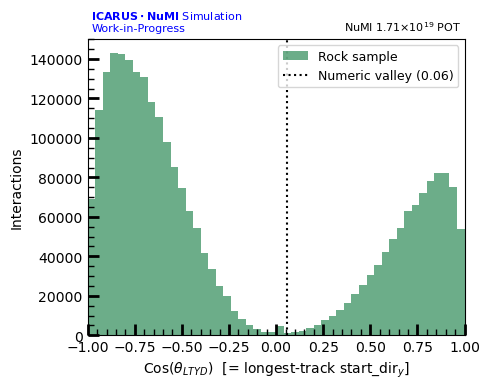


--- rock, Cos(theta_LTYD) summary ---
  total rows                        : 2785031
  valid (finite, non-degenerate dir) : 2656154 (95.4%)

  at Roy's threshold (-0.7), among valid rows:
    cos_theta_y <= -0.7 (would be CUT)  : 942294 (35.5%)
    cos_theta_y >  -0.7 (kept)           : 1713860 (64.5%)

  at the numeric valley (0.060), among valid rows:
    cos_theta_y <= 0.060 (would be CUT)  : 1766719 (66.5%)
    cos_theta_y >  0.060 (kept)           : 889435 (33.5%)
  within 'true_category != 9' (664 rows): 13.7% fall below Roy's threshold, 58.4% fall below the numeric valley
  within 'true_category == 9 (Cosmic)' (2637142 rows): 35.6% fall below Roy's threshold, 66.6% fall below the numeric valley

Done. Compare the numeric-valley split against true_category above -- if true_category==9 rows are concentrated below the valley and true_category!=9 rows above it, the valley is a well-motivated cut to apply to the rock sample before the trigger-time plot.


In [35]:
# ============================================================================
# Rock-vs-cosmic angular separation study (advisor's suggestion).
#
# Physical picture: rock muons come from a beam neutrino interacting in the
# rock/dirt surrounding the cryostat (confirmed directly from the C++ source
# -- see evar::n_true_nu's docstring in event_variables.h), so they enter
# close to the NuMI beam direction, i.e. close to horizontal (along Z).
# Standalone cosmic-ray muons (the contamination we're trying to separate
# out, per Howard's Fig. 8 note on "simulated cosmic muons from before the
# beam spill providing the trigger") enter close to vertical, dominated by
# downward flux along -Y. This is the same variable Roy's technote calls
# Cos(theta_LTYD) (Sec. 4.1, Fig. 6): the cosine of the angle between the
# longest track and the vertical (Y) axis -- neutrino/beam-like tracks
# cluster near 0 (perpendicular to Y), cosmics cluster near -1 (downward).
#
# New branches (added to preselection.toml this session, selector =
# "longest_track" rather than the PID-based "leading_muon" used elsewhere
# in this notebook -- geometric, not PID-based, so it doesn't depend on a
# muon-score call to work on a rock event that may not PID as a clean muon):
#   reco_longest_track_start_dir_{x,y,z}, reco_longest_track_length
# Naming convention confirmed directly from framework.cc's construct():
# for type="reco_particle" with a selector, the branch is named
# "reco_" + selector + "_" + name.
#
# Cos(theta_LTYD) = start_dir_y already, PROVIDED start_dir is a unit
# vector; this cell computes it from the normalized (x,y,z) instead of
# assuming that, so a non-unit vector wouldn't silently bias the result.
#
# v3 change: the v2 run showed n_true_nu is an uninformative cross-check at
# this granularity (0 of 2,656,154 valid rows had n_true_nu==0 -- it's an
# event-level quantity broadcast onto preselection's per-INTERACTION rows,
# and can't discriminate between the ~14.5 reconstructed interactions that
# exist, on average, per rock-triggering event). true_category (already
# loaded, per-interaction) is used instead. v3 also finds the valley
# between the two lobes numerically rather than eyeballing it off the plot,
# since the v2 plot showed the valley is NOT at Roy's -0.7.
#
# Self-contained: re-imports and re-defines everything it needs.
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import uproot

# ------------------------------------------------------------------ config --
DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/preselection.root")

OUTPUT_DIR = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
              "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
              "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
              "ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/"
              "1muNp0pi_Nge1_uncontained/preselection")

ROY_THRESHOLD = -0.7  # her cut: Cos(theta_LTYD) > -0.7 retains signal-like tracks

# ------------------------------------------------------------------ style ---
# Same conventions as the trigger-time/preselection-plots cells, so this
# figure matches the rest of the notebook rather than looking like a
# separate diagnostic script.
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    # Blue, not the "chocolate" brown used for the Data label in the other
    # cells -- this cell is Simulation-only (rock), so it gets its own color
    # rather than reusing the Data-labeled cells' convention.
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + subtitle,
            fontsize=8, color="blue", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

print(f"CELL VERSION: rock_angular_separation_v8_pot_label_2026-08-20")
print(f"Opening {DATA_FILE} ...")
f = uproot.open(DATA_FILE)

# Rock's own generated POT (this is a Simulation-only plot, so the relevant
# exposure to show is the rock production's POT, not onbeam data POT) --
# same histogram-first read pattern as read_exposure() in the trigger-time/
# preselection-plots cells.
if "events/rock/POT" in f:
    ROCK_POT = f["events/rock/POT"].values().sum()
    print(f"Rock POT (from events/rock/POT histogram): {ROCK_POT:.6e}")
else:
    key = "events/rock/preselection_exposure"
    if key not in f:
        raise KeyError("no exposure information found for rock "
                        "(looked for events/rock/POT and events/rock/preselection_exposure)")
    arrays = f[key].arrays(library="np")
    ROCK_POT = None
    for name, vals in arrays.items():
        if "pot" in name.lower():
            ROCK_POT = float(np.nansum(vals))
    if ROCK_POT is None:
        raise KeyError(f"no POT-like branch found in {key}: {list(arrays.keys())}")
    print(f"Rock POT (from {key}): {ROCK_POT:.6e}")

# ------------------------------------------------------------- load rock ---
# Pull the new geometric branches plus join keys and the existing true_category
# branch (already on preselection) for a first-pass sanity split.
rock_needed = ["Run", "Subrun", "Evt", "true_category"]
# Exact reco-level names, confirmed from framework.cc's construct(): for
# type="reco_particle" with a selector, the branch is "reco_" + selector +
# "_" + name. An endswith() filter alone is NOT safe here -- it matches
# both the "reco_" and "true_" versions of the same suffix (both_particle
# builds both), so we require the "reco_" prefix explicitly too.
rock_dir_candidates = {
    "start_dir_x": [c for c in f["events/rock/preselection"].keys()
                     if c.startswith("reco_") and c.endswith("longest_track_start_dir_x")],
    "start_dir_y": [c for c in f["events/rock/preselection"].keys()
                     if c.startswith("reco_") and c.endswith("longest_track_start_dir_y")],
    "start_dir_z": [c for c in f["events/rock/preselection"].keys()
                     if c.startswith("reco_") and c.endswith("longest_track_start_dir_z")],
    "length":      [c for c in f["events/rock/preselection"].keys()
                     if c.startswith("reco_") and c.endswith("longest_track_length")],
}
for key, cands in rock_dir_candidates.items():
    if len(cands) != 1:
        raise KeyError(f"expected exactly one column starting with 'reco_' and ending in "
                        f"'longest_track_{key}' on events/rock/preselection, found {cands}. "
                        f"Available columns: {list(f['events/rock/preselection'].keys())}")
DIR_COLS = {k: v[0] for k, v in rock_dir_candidates.items()}
print(f"Resolved longest_track direction columns: {DIR_COLS}")

rock = f["events/rock/preselection"].arrays(
    rock_needed + list(DIR_COLS.values()), library="pd")
print(f"rock/preselection: {len(rock)} rows")

# ------------------------------------- cross-check via true_category ------
# NOTE (v2 finding): n_true_nu is an event-level quantity -- broadcasting it
# onto preselection's per-INTERACTION rows can't discriminate between the
# ~14.5 reconstructed interactions that exist, on average, per rock-
# triggering event (2,785,031 preselection rows / 191,720 trigger_time
# events, from the v2 run). It came back 100% n_true_nu>0 with zero
# exceptions -- not a bug, just an uninformative cross-check at this
# granularity. true_category (already loaded above) is evaluated per
# INTERACTION, same granularity as cos_theta_y, so it's used instead:
# category 9 = "Cosmic" (cuts::neutrino fails for this specific
# interaction) is the relevant split.
print(f"\n  true_category value counts (rock/preselection, all rows):")
print(rock["true_category"].value_counts().sort_index().to_string())

# ------------------------------------------------------ compute cos(theta) --
vx = rock[DIR_COLS["start_dir_x"]].values
vy = rock[DIR_COLS["start_dir_y"]].values
vz = rock[DIR_COLS["start_dir_z"]].values
norm = np.sqrt(vx**2 + vy**2 + vz**2)

# Sentinel/invalid guard: rows with no valid longest-track direction (e.g. no
# reconstructed particle at all in that interaction) show up as norm <= 0 or
# non-finite -- exclude them explicitly rather than silently propagating NaN
# into the histogram.
valid = np.isfinite(norm) & (norm > 0)
n_invalid = int((~valid).sum())
print(f"\n  excluded as invalid longest-track direction (norm <= 0 or non-finite): "
      f"{n_invalid} / {len(rock)} rows ({n_invalid/len(rock):.1%})")

cos_theta_y = np.full(len(rock), np.nan)
cos_theta_y[valid] = vy[valid] / norm[valid]

true_cat = rock["true_category"].values
is_cosmic_cat = valid & np.isfinite(true_cat) & (true_cat == 9)
is_nu_cat     = valid & np.isfinite(true_cat) & (true_cat != 9)

# ------------------------------------------------------- valley-finding ----
# Numeric local minimum between the two lobes, from the binned counts
# themselves (not eyeballed off the plot). Restrict the search to the
# interior of the range so an edge bin can't spuriously "win".
BINS = np.linspace(-1.0, 1.0, 51)
bin_centers = 0.5 * (BINS[:-1] + BINS[1:])
counts_all, _ = np.histogram(cos_theta_y[valid], bins=BINS)
search_lo, search_hi = 15, 35  # bin_centers ~ -0.4 to +0.4, away from both peaks
interior = counts_all[search_lo:search_hi]
valley_bin = search_lo + int(np.argmin(interior))
VALLEY = bin_centers[valley_bin]
print(f"\n  numeric valley (local min of binned counts, searched in "
      f"[{bin_centers[search_lo]:.2f}, {bin_centers[search_hi]:.2f}]): "
      f"Cos(theta_LTYD) = {VALLEY:.3f} (bin count = {counts_all[valley_bin]})")

# --------------------------------------------------------------- plotting ---
# Single panel, full longest-track angular distribution, ICARUS-style
# cosmetics (matching the trigger-time/preselection-plots cells) -- no
# true_category split panel, per instruction.
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(cos_theta_y[valid], bins=BINS, histtype="stepfilled",
        color="seagreen", alpha=0.7, label="Rock sample")
ax.axvline(VALLEY, color="k", linestyle=":", linewidth=1.5,
           label=f"Numeric valley ({VALLEY:.2f})")
ax.set_xlabel(r"Cos($\theta_{LTYD}$)  [= longest-track start_dir$_y$]")
ax.set_ylabel("Interactions")
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc="upper right")
apply_tick_style(ax)
add_icarus_label(ax)
add_pot_label(ax, f"NuMI {ROCK_POT/1e19:.2f}" + r"$\times 10^{19}$ POT")
fig.tight_layout()

os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "pdf/rock_angular_separation.pdf"),
            bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, "jpeg/rock_angular_separation.jpeg"),
            bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

# ------------------------------------------------------------- summary ------
print(f"\n--- rock, Cos(theta_LTYD) summary ---")
print(f"  total rows                        : {len(rock)}")
print(f"  valid (finite, non-degenerate dir) : {valid.sum()} ({valid.sum()/len(rock):.1%})")

below_roy = valid & (cos_theta_y <= ROY_THRESHOLD)
above_roy = valid & (cos_theta_y >  ROY_THRESHOLD)
print(f"\n  at Roy's threshold ({ROY_THRESHOLD}), among valid rows:")
print(f"    cos_theta_y <= {ROY_THRESHOLD} (would be CUT)  : "
      f"{below_roy.sum()} ({below_roy.sum()/valid.sum():.1%})")
print(f"    cos_theta_y >  {ROY_THRESHOLD} (kept)           : "
      f"{above_roy.sum()} ({above_roy.sum()/valid.sum():.1%})")

below_val = valid & (cos_theta_y <= VALLEY)
above_val = valid & (cos_theta_y >  VALLEY)
print(f"\n  at the numeric valley ({VALLEY:.3f}), among valid rows:")
print(f"    cos_theta_y <= {VALLEY:.3f} (would be CUT)  : "
      f"{below_val.sum()} ({below_val.sum()/valid.sum():.1%})")
print(f"    cos_theta_y >  {VALLEY:.3f} (kept)           : "
      f"{above_val.sum()} ({above_val.sum()/valid.sum():.1%})")

for label, mask in (("true_category != 9", is_nu_cat), ("true_category == 9 (Cosmic)", is_cosmic_cat)):
    if mask.sum() == 0:
        continue
    fr_roy = (mask & below_roy).sum() / mask.sum()
    fr_val = (mask & below_val).sum() / mask.sum()
    print(f"  within '{label}' ({mask.sum()} rows): "
          f"{fr_roy:.1%} fall below Roy's threshold, {fr_val:.1%} fall below the numeric valley")

print("\nDone. Compare the numeric-valley split against true_category above -- if "
      "true_category==9 rows are concentrated below the valley and true_category!=9 "
      "rows above it, the valley is a well-motivated cut to apply to the rock sample "
      "before the trigger-time plot.")


CELL VERSION: nocuts_3comp_v6_inwindow_localstyle_2026-08-22

Reading exposures (preselection_nocuts tree)...
Nominal MC POT (raw, from file) : 7.7852e+20
Nominal MC POT (corrected)      : 7.1784e+20
MC scale:      3.2894e-02
Offbeam scale: 9.5295e-02
Rock scale:    1.3835e+00

Loading 'preselection_nocuts' trees (branch-filtered)...
   nominal: 55088959 rows
      rock: 7808842 rows
    onbeam: 3202605 rows
   offbeam: 19470760 rows

Applying in-beam-window requirement (reco_flash_time in [0.0, 9.6] us, finite):
   nominal: 55088959 -> 1308441  (2.38% kept, in [0.0, 9.6] us with a matched flash)
      rock: 7808842 -> 34329  (0.44% kept, in [0.0, 9.6] us with a matched flash)
    onbeam: 3202605 -> 99444  (3.11% kept, in [0.0, 9.6] us with a matched flash)
   offbeam: 19470760 -> 550020  (2.82% kept, in [0.0, 9.6] us with a matched flash)
Mean PPFX weight (nominal, in-window subset): 0.9670

Rock angular (directionality) cut: 34329 -> 8115 (23.6% kept)

--- nocuts_inwindow_vertex_x (z

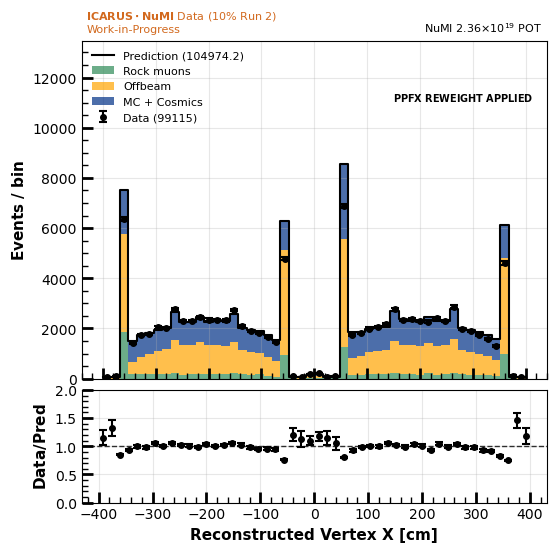


--- nocuts_inwindow_vertex_y (zero-cut, in-beam-window, 3-component) ---
          MC: frac= 0.395  events=   41608.0
        Rock: frac= 0.107  events=   11227.2
     Offbeam: frac= 0.498  events=   52413.7
        PRED: frac= 1.000  events=  105248.9
        DATA:                 events=     99437
  data/pred = 0.9448


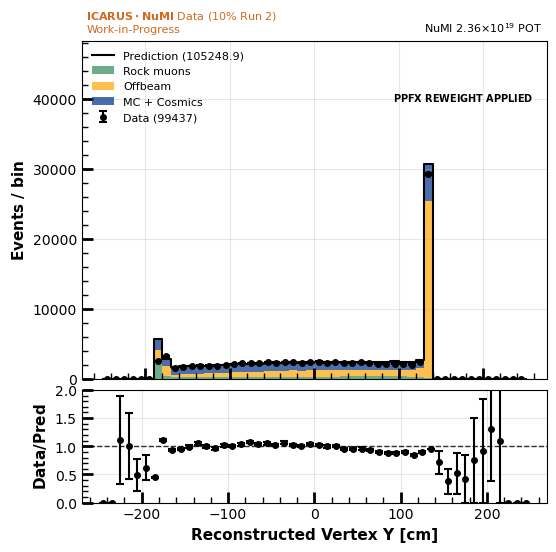


--- nocuts_inwindow_vertex_z (zero-cut, in-beam-window, 3-component) ---
          MC: frac= 0.395  events=   41613.4
        Rock: frac= 0.107  events=   11227.2
     Offbeam: frac= 0.498  events=   52414.0
        PRED: frac= 1.000  events=  105254.7
        DATA:                 events=     99442
  data/pred = 0.9448


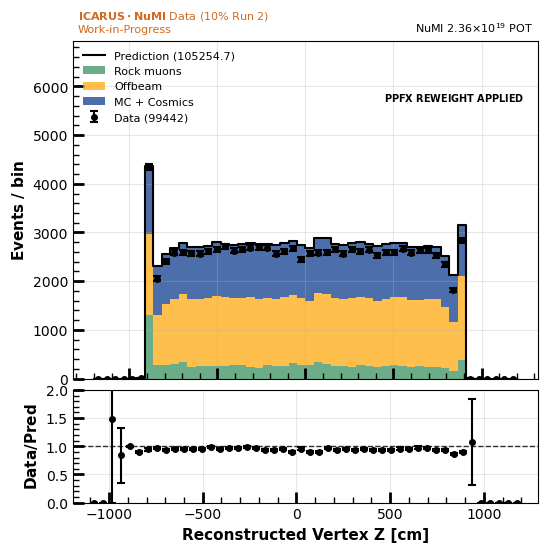


Done.


In [36]:
# ============================================================================
# ZERO-CUT vertex X/Y/Z comparison, 3-component stack.
#
# Reads the `preselection_nocuts` tree: identical branch list to
# `preselection`, but every slice/spill cut commented out -- no fiducial_cut,
# no trigger_emulation_cut, no data_quality_cut, no crtpmt_veto. This matches
# the stage of Roy's inclusive technote Appendix A.2 / Fig. 9 vertex X plot
# ("without applying any slice level or spill level cut"). This cell reuses
# DATA_FILE/ONBEAM_POT/POT_CORRECTION_FACTOR/OUTPUT_DIR/ROCK_ANGULAR_VALLEY/
# compute_ppfx from the trigger-time cell above (run that cell first). The
# plot-style helpers (apply_tick_style, add_icarus_label, add_pot_label,
# add_corner_label) are LOCAL copies defined in this cell, not reused from
# cell 0/1's globals -- see the comment right above their definitions below
# for why (cell 0 and cell 1 each define a same-named add_icarus_label with
# different text -- "Data" vs "Simulation" -- and whichever ran last wins in
# the shared kernel namespace, which is not safe to depend on here).
#
# IN-BEAM-WINDOW REQUIREMENT (added 2026-08-22): every sample is additionally
# required to have reco_flash_time finite AND inside [0.0, 9.6] us -- applied
# uniformly to nominal/rock/onbeam/offbeam alike, not singled out for any one
# sample. Justification: the signal-timing check (a separate cell) showed
# that for nominal, true_category 0-8 (real beam-neutrino-truth-matched) rows
# land inside the beam window 99.68% of the time when they have a matched
# flash at all -- i.e. genuine beam interactions are correctly timed. The
# 28.33%-outside-window population comes from true_category 9 (Cosmic) rows,
# which have no beam association and are not confined to the spill by
# physics. Real data likewise cannot produce a genuine beam interaction
# outside the actual spill, so anything (in any sample) with a flash time
# outside [0, 9.6] cannot represent in-beam activity -- it's removed here so
# the comparison isolates in-time candidates only, while still applying none
# of the FV/trigger/data-quality slice/spill cuts.
#
# Stack: 3 components, no truth-category split.
#   MC + Cosmics = the full nominal simulation (signal + its embedded
#                   out-of-time cosmic simulation), unsplit by true_category.
#   Offbeam      = in-time cosmic estimated from beam-off data.
#   Rock muons   = the dedicated rock-muon production, after the
#                   directionality (Cos(theta_LTYD) > ROCK_ANGULAR_VALLEY)
#                   separation cut -- the same rock-vs-cosmic separation
#                   procedure justified in the cell above, applied here to
#                   remove cosmic contamination from the rock-muon sample
#                   based on track direction.
#
# NOTE (open question, not resolved by this cell): the directionality cut
# separates rock-like tracks from cosmic-like contamination WITHIN the rock
# production. It does not check whether a surviving rock-like row is also
# independently captured by the offbeam sample (Howard's technote, Sec.
# 6.8.7 / Fig. 91, flags this as a real double-counting risk for dirt/rock
# samples). That check needs `n_true_nu`, which exists only on the
# `trigger_time` (event-mode) tree, not here. Not addressed in this cell.
#
# No rebuild needed beyond what's already been done (this tree already
# exists in preselection.root per the toml you added).
# ============================================================================

print("CELL VERSION: nocuts_3comp_v6_inwindow_localstyle_2026-08-22")

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

# ---- LOCAL copies of the style helpers, not the shared globals from cells
# 0/1. All three cells share one kernel namespace, and both cell 0 and cell
# 1 define a module-level `add_icarus_label` (cell 0's says "Data", cell 1's
# says "Simulation" -- rock is a simulation-only sample there). Whichever
# cell last ran clobbers the other's definition, so relying on the shared
# name silently picks up whichever text happened to run last -- that's
# exactly how this plot ended up mislabeled "Simulation" when it overlays
# real onbeam data against a prediction and should say "Data", matching
# cell 0. Defining these here, local to this cell, makes the label correct
# regardless of cell run order. Tick style and POT label are identical to
# cell 0/1's, so those are just copied as-is (no dispute there); only the
# ICARUS label differs and needed a fix.
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

TREE_NOCUTS = "preselection_nocuts"

f2 = uproot.open(DATA_FILE)  # same file as cell 1, reopened for a clean scope

def read_exposure_local(sample, tree=TREE_NOCUTS):
    pot = lt = None
    if f"events/{sample}/POT" in f2:
        pot = f2[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f2:
        lt = f2[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f2:
        raise KeyError(f"no exposure info for '{sample}' (tree={tree})")
    arrays = f2[key].arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt

print(f"\nReading exposures ({TREE_NOCUTS} tree)...")
_,           onbeam_lt_nc  = read_exposure_local("onbeam")
_,           offbeam_lt_nc = read_exposure_local("offbeam")
rock_pot_nc,     _         = read_exposure_local("rock")
nominal_pot_raw_nc, _      = read_exposure_local("nominal")

nominal_pot_nc = nominal_pot_raw_nc * POT_CORRECTION_FACTOR  # same fixed
                                                              # production-wide
                                                              # loss fraction
                                                              # as cell 1
mc_scale_nc      = ONBEAM_POT / nominal_pot_nc
offbeam_scale_nc = onbeam_lt_nc / offbeam_lt_nc
rock_scale_nc    = ONBEAM_POT / rock_pot_nc

print(f"Nominal MC POT (raw, from file) : {nominal_pot_raw_nc:.4e}")
print(f"Nominal MC POT (corrected)      : {nominal_pot_nc:.4e}")
print(f"MC scale:      {mc_scale_nc:.4e}")
print(f"Offbeam scale: {offbeam_scale_nc:.4e}")
print(f"Rock scale:    {rock_scale_nc:.4e}")

# Only pull the branches this cell actually touches downstream -- pulling
# every branch in the tree (calorimetry arrays, per-particle vectors, etc.)
# is unnecessary weight, and preselection_nocuts has more rows than
# preselection (no fiducial/trigger/DQ cuts to shrink it), so the cost of
# over-fetching is larger here than it was in cell 1.
_VTX_BR   = ["reco_vertex_x", "reco_vertex_y", "reco_vertex_z", "reco_flash_time"]
_MC_BR    = _VTX_BR + ["true_pdg", "true_neutrino_energy"]  # compute_ppfx needs these; no
                                                             # true_category, no truth split
_ROCK_BR  = _VTX_BR + ["reco_longest_track_start_dir_x",
                       "reco_longest_track_start_dir_y",
                       "reco_longest_track_start_dir_z"]

print(f"\nLoading '{TREE_NOCUTS}' trees (branch-filtered)...")
mc_nc      = f2[f"events/nominal/{TREE_NOCUTS}"].arrays(_MC_BR, library="pd")
rock_nc    = f2[f"events/rock/{TREE_NOCUTS}"].arrays(_ROCK_BR, library="pd")
onbeam_nc  = f2[f"events/onbeam/{TREE_NOCUTS}"].arrays(_VTX_BR, library="pd")
offbeam_nc = f2[f"events/offbeam/{TREE_NOCUTS}"].arrays(_VTX_BR, library="pd")

for name, df in (("nominal", mc_nc), ("rock", rock_nc), ("onbeam", onbeam_nc),
                 ("offbeam", offbeam_nc)):
    print(f"  {name:>8}: {len(df)} rows")

# ---- in-beam-window requirement, applied uniformly to all four samples ----
FLASH_LO, FLASH_HI = 0.0, 9.6
def apply_in_window(df, name):
    ft = df["reco_flash_time"].values
    mask = np.isfinite(ft) & (ft >= FLASH_LO) & (ft <= FLASH_HI)
    n_before = len(df)
    out = df[mask].reset_index(drop=True)
    print(f"  {name:>8}: {n_before} -> {len(out)}  ({len(out)/n_before:.2%} kept, in "
          f"[{FLASH_LO}, {FLASH_HI}] us with a matched flash)")
    return out

print(f"\nApplying in-beam-window requirement (reco_flash_time in "
      f"[{FLASH_LO}, {FLASH_HI}] us, finite):")
mc_nc      = apply_in_window(mc_nc,      "nominal")
rock_nc    = apply_in_window(rock_nc,    "rock")
onbeam_nc  = apply_in_window(onbeam_nc,  "onbeam")
offbeam_nc = apply_in_window(offbeam_nc, "offbeam")

# ---- PPFX weighting (same logic/inputs as cell 1) ----
mc_nc["ppfx_weight"] = compute_ppfx(mc_nc)
print(f"Mean PPFX weight (nominal, in-window subset): {mc_nc['ppfx_weight'].mean():.4f}")

# ---- rock angular (directionality) cut -- the procedure built to separate
# rock-like tracks from cosmic contamination within the rock production,
# same fixed threshold as cell 1. NOT one of the "slice/spill level" cuts
# being tested by this zero-cut comparison -- this is sample purification,
# applied the same way regardless of which tree feeds this cell.
_vx = rock_nc["reco_longest_track_start_dir_x"].values
_vy = rock_nc["reco_longest_track_start_dir_y"].values
_vz = rock_nc["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
_cos_theta_y = np.full(len(rock_nc), np.nan)
_cos_theta_y[_valid_dir] = _vy[_valid_dir] / _norm[_valid_dir]
_is_rocklike = _valid_dir & (_cos_theta_y > ROCK_ANGULAR_VALLEY)
n_rock_before_nc = len(rock_nc)
rock_nc = rock_nc[_is_rocklike].reset_index(drop=True)
print(f"\nRock angular (directionality) cut: {n_rock_before_nc} -> {len(rock_nc)} "
      f"({len(rock_nc)/n_rock_before_nc:.1%} kept)")

# --------------------------------------------------------- 3-comp stack ---
# Back to a single combined nominal component (MC + Cosmics, unsplit by
# true_category) -- same palette/format as the trigger-time cell above
# (cell 0): blue "#003087" for the combined nominal simulation, "orange"
# for offbeam, "seagreen" for rock, black for data/prediction.
STACK = [
    ("MC",      "MC + Cosmics", "#003087"),
    ("Rock",    "Rock muons",   "seagreen"),
    ("Offbeam", "Offbeam",      "orange"),
]

def nocuts_case(variable, xlabel, bins, output_suffix):
    bins = np.asarray(bins, dtype=float)
    centers = 0.5 * (bins[:-1] + bins[1:])
    width   = bins[1:] - bins[:-1]

    w_mc = mc_nc["ppfx_weight"].values * mc_scale_nc
    mc_h = np.histogram(mc_nc[variable].values, bins=bins, weights=w_mc)[0]
    rk_h = np.histogram(rock_nc[variable].values, bins=bins,
                        weights=np.full(len(rock_nc), rock_scale_nc))[0]
    off_h = np.histogram(offbeam_nc[variable].values, bins=bins,
                         weights=np.full(len(offbeam_nc), offbeam_scale_nc))[0]
    dat_h = np.histogram(onbeam_nc[variable].values, bins=bins)[0]
    n_data = int(dat_h.sum())
    dat_err = np.sqrt(dat_h)

    comps = {"MC": mc_h, "Rock": rk_h, "Offbeam": off_h}
    pred = sum(comps[k] for k, _, _ in STACK)
    tot = pred.sum()

    print(f"\n--- {output_suffix} (zero-cut, in-beam-window, 3-component) ---")
    for k, lab, _ in STACK:
        s = comps[k].sum()
        print(f"  {k:>10}: frac={s/tot:6.3f}  events={s:10.1f}")
    print(f"  {'PRED':>10}: frac={1.0:6.3f}  events={tot:10.1f}")
    print(f"  {'DATA':>10}: {'':>15} events={n_data:10d}")
    print(f"  data/pred = {n_data/tot:.4f}")

    # ---- figure, same format/helpers as the trigger-time cell above (cell 0):
    # apply_tick_style / add_icarus_label / add_pot_label are defined there
    # and reused here as-is, not reimplemented, so both plots in this
    # notebook look identical in style.
    fig = plt.figure(figsize=(6, 6))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax, axr = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    # Stacking order bottom-to-top: rock, offbeam, MC -- same bottom-up
    # convention as cell 0 (rock/offbeam low, nu+cosmic sim drawn last/on
    # top).
    draw_order = ["Rock", "Offbeam", "MC"]
    label_of = {k: lab for k, lab, _ in STACK}
    color_of = {k: col for k, _, col in STACK}
    base = np.zeros(len(bins) - 1)
    for k in draw_order:
        ax.bar(centers, comps[k], width=width, bottom=base, color=color_of[k],
               alpha=0.7, label=label_of[k])
        base = base + comps[k]
    ax.step(np.append(bins[:-1], bins[-1]), np.append(pred, pred[-1]),
            where='post', color='black', linewidth=1.5,
            label=f"Prediction ({tot:.1f})")
    ax.errorbar(centers, dat_h, yerr=dat_err, fmt='o', markersize=4,
                markerfacecolor="black", markeredgecolor="black", color="black",
                capsize=3, capthick=1.5, elinewidth=1.5,
                label=f"Data ({n_data})", zorder=5)

    ax.set_ylabel(r"$\mathbf{Events\ /\ bin}$", fontsize=11, fontfamily="sans-serif")
    ax.grid(True, alpha=0.3)
    apply_tick_style(ax)
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, l, fontsize=8, loc='upper left', framealpha=0.0, edgecolor='none')
    add_icarus_label(ax)
    pot_str_nc = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"
    add_pot_label(ax, pot_str_nc)
    # Same PPFX-applied indicator cell 0 shows -- this plot's MC + Cosmics
    # component IS PPFX-reweighted (mc_nc["ppfx_weight"] via compute_ppfx,
    # applied in w_mc above), so the label reads "APPLIED" here too, not
    # conditional on anything -- this cell only ever runs the PPFX-applied
    # case, unlike cell 0 which also has a no-PPFX comparison case.
    add_corner_label(ax, r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$')

    with np.errstate(invalid="ignore", divide="ignore"):
        r = np.where(pred > 0, dat_h / pred, np.nan)
        re = np.where(pred > 0, dat_err / pred, np.nan)
    axr.errorbar(centers, r, yerr=re, fmt='o', markersize=4,
                 markerfacecolor='black', markeredgecolor='black', color='black',
                 capsize=3, capthick=1.5, elinewidth=1.5)
    axr.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    axr.set_ylim(0.0, 2.0)
    axr.set_ylabel(r"$\mathbf{Data/Pred}$", fontsize=11)
    axr.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    axr.grid(True, alpha=0.3)
    apply_tick_style(axr)

    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_suffix}.jpeg"),
                bbox_inches="tight", dpi=200)
    plt.show()
    plt.close(fig)


NOCUTS_SPECS = [
    ("reco_vertex_x", "Reconstructed Vertex X [cm]", np.linspace(-400, 400, 51),
     "nocuts_inwindow_vertex_x"),
    ("reco_vertex_y", "Reconstructed Vertex Y [cm]", np.linspace(-250, 250, 51),
     "nocuts_inwindow_vertex_y"),
    ("reco_vertex_z", "Reconstructed Vertex Z [cm]", np.linspace(-1200, 1200, 51),
     "nocuts_inwindow_vertex_z"),
]
for var, xl, b, suff in NOCUTS_SPECS:
    nocuts_case(var, xl, b, suff)

print("\nDone.")


CELL VERSION: presel_3comp_v1_inwindow_2026-08-22

Reading exposures (preselection tree)...
Nominal MC POT (raw, from file) : 7.7852e+20
Nominal MC POT (corrected)      : 7.1784e+20
MC scale:      3.2894e-02
Offbeam scale: 9.5295e-02
Rock scale:    1.3835e+00

Loading 'preselection' trees (branch-filtered)...
   nominal: 19922850 rows
      rock: 2785031 rows
    onbeam: 1129259 rows
   offbeam: 5816828 rows

Applying in-beam-window requirement (reco_flash_time in [0.0, 9.6] us, finite):
   nominal: 19922850 -> 571526  (2.87% kept, in [0.0, 9.6] us with a matched flash)
      rock: 2785031 -> 2672  (0.10% kept, in [0.0, 9.6] us with a matched flash)
    onbeam: 1129259 -> 26733  (2.37% kept, in [0.0, 9.6] us with a matched flash)
   offbeam: 5816828 -> 35396  (0.61% kept, in [0.0, 9.6] us with a matched flash)
Mean PPFX weight (nominal, in-window subset): 0.9609

Rock angular (directionality) cut: 2672 -> 1006 (37.6% kept)

--- presel_inwindow_vertex_x (preselection, in-beam-window, 3-

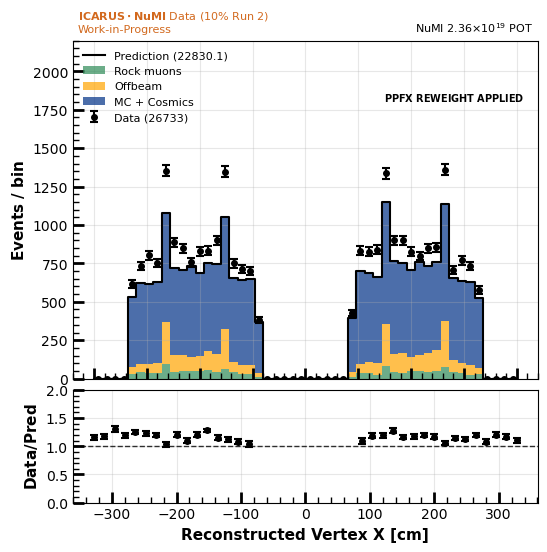


--- presel_inwindow_vertex_y (preselection, in-beam-window, 3-component) ---
          MC: frac= 0.791  events=   18065.2
        Rock: frac= 0.061  events=    1391.8
     Offbeam: frac= 0.148  events=    3373.1
        PRED: frac= 1.000  events=   22830.1
        DATA:                 events=     26733
  data/pred = 1.1710


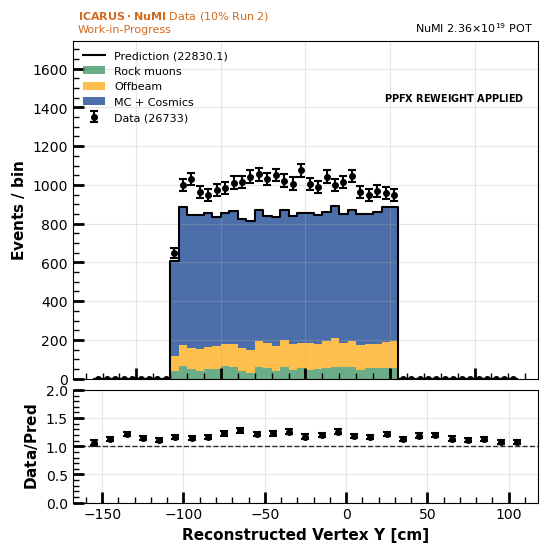


--- presel_inwindow_vertex_z (preselection, in-beam-window, 3-component) ---
          MC: frac= 0.791  events=   18065.2
        Rock: frac= 0.061  events=    1391.8
     Offbeam: frac= 0.148  events=    3373.1
        PRED: frac= 1.000  events=   22830.1
        DATA:                 events=     26733
  data/pred = 1.1710


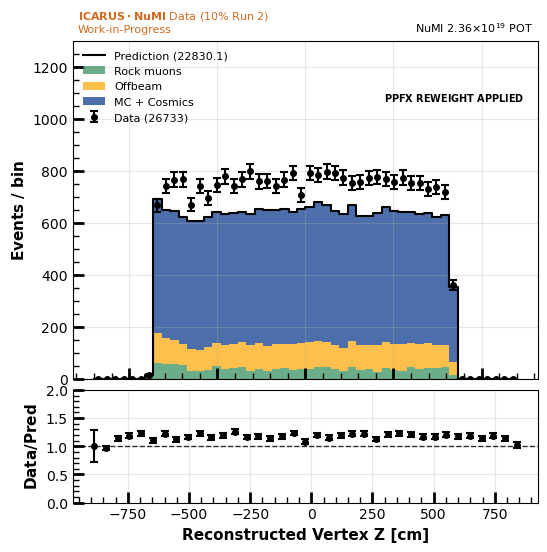


Done.


In [3]:
# ============================================================================
# Standard preselection-tree vertex X/Y/Z comparison, 3-component stack.
#
# Reads the `preselection` tree (not `preselection_nocuts`): this tree
# already has the framework's three applied cuts baked in --
# fiducial_cut, trigger_emulation_cut, and data_quality_cut (see
# selection/toml/preselection.toml's `cut = [...]` list for this tree).
# `crtpmt_veto` is commented out in that same list, so it is NOT applied
# here either.
#
# Why this cell exists: an earlier version of this comparison, built on
# this same `preselection` tree, showed a ~17% data excess (data 26733 vs
# prediction 22797.9). Checking the toml/cuts.h directly (not guessing)
# showed why: `flash_cut` -- which DOES receive the correct
# [flash_low_t, flash_high_t] = [0.0, 9.6] window as parameters -- is
# listed under this tree's `branch = [...]` block, not its `cut = [...]`
# block. That means `reco_flash_cut` exists as a computed true/false
# column in the tree, but it was never actually used to filter rows at
# the tree-production level -- every candidate that passes FV + trigger +
# DQ stays in the tree regardless of what `reco_flash_cut` says about it.
# So the same missing-in-window-timing-requirement issue that was found
# and fixed on the zero-cut tree (see the cell above) was very plausibly
# never fixed here either -- this cell tests that directly, on the tree
# that actually has the topological/spill-level cuts applied, rather than
# the zero-cut tree.
#
# IN-BEAM-WINDOW REQUIREMENT: identical to the cell above -- every sample
# is additionally required to have reco_flash_time finite AND inside
# [0.0, 9.6] us, applied uniformly to nominal/rock/onbeam/offbeam alike,
# as a post-hoc pandas-level filter (since the tree itself does not apply
# it, per the finding above).
#
# Stack: 3 components, no truth-category split -- same convention as the
# zero-cut cell above.
#   MC + Cosmics = the full nominal simulation (signal + its embedded
#                   out-of-time cosmic simulation), unsplit by true_category.
#   Offbeam      = in-time cosmic estimated from beam-off data.
#   Rock muons   = the dedicated rock-muon production, after the
#                   directionality (Cos(theta_LTYD) > ROCK_ANGULAR_VALLEY)
#                   separation cut, same as the cells above.
#
# Reuses DATA_FILE/ONBEAM_POT/POT_CORRECTION_FACTOR/OUTPUT_DIR/
# ROCK_ANGULAR_VALLEY/compute_ppfx from the trigger-time cell above (run
# that cell first). Plot-style helpers are LOCAL copies, same reasoning
# as the zero-cut cell above (cell 0/1's shared-namespace add_icarus_label
# is not safe to depend on here).
# ============================================================================

print("CELL VERSION: presel_3comp_v1_inwindow_2026-08-22")

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

TREE_PRESEL = "preselection"

f3 = uproot.open(DATA_FILE)  # reopened for a clean scope, same file as the cells above

def read_exposure_presel(sample, tree=TREE_PRESEL):
    pot = lt = None
    if f"events/{sample}/POT" in f3:
        pot = f3[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f3:
        lt = f3[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f3:
        raise KeyError(f"no exposure info for '{sample}' (tree={tree})")
    arrays = f3[key].arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt

print(f"\nReading exposures ({TREE_PRESEL} tree)...")
_,             onbeam_lt_pc  = read_exposure_presel("onbeam")
_,             offbeam_lt_pc = read_exposure_presel("offbeam")
rock_pot_pc,       _         = read_exposure_presel("rock")
nominal_pot_raw_pc, _        = read_exposure_presel("nominal")

nominal_pot_pc = nominal_pot_raw_pc * POT_CORRECTION_FACTOR
mc_scale_pc      = ONBEAM_POT / nominal_pot_pc
offbeam_scale_pc = onbeam_lt_pc / offbeam_lt_pc
rock_scale_pc    = ONBEAM_POT / rock_pot_pc

print(f"Nominal MC POT (raw, from file) : {nominal_pot_raw_pc:.4e}")
print(f"Nominal MC POT (corrected)      : {nominal_pot_pc:.4e}")
print(f"MC scale:      {mc_scale_pc:.4e}")
print(f"Offbeam scale: {offbeam_scale_pc:.4e}")
print(f"Rock scale:    {rock_scale_pc:.4e}")

_VTX_BR   = ["reco_vertex_x", "reco_vertex_y", "reco_vertex_z", "reco_flash_time"]
_MC_BR    = _VTX_BR + ["true_pdg", "true_neutrino_energy"]  # compute_ppfx needs these
_ROCK_BR  = _VTX_BR + ["reco_longest_track_start_dir_x",
                       "reco_longest_track_start_dir_y",
                       "reco_longest_track_start_dir_z"]

print(f"\nLoading '{TREE_PRESEL}' trees (branch-filtered)...")
mc_pc      = f3[f"events/nominal/{TREE_PRESEL}"].arrays(_MC_BR, library="pd")
rock_pc    = f3[f"events/rock/{TREE_PRESEL}"].arrays(_ROCK_BR, library="pd")
onbeam_pc  = f3[f"events/onbeam/{TREE_PRESEL}"].arrays(_VTX_BR, library="pd")
offbeam_pc = f3[f"events/offbeam/{TREE_PRESEL}"].arrays(_VTX_BR, library="pd")

for name, df in (("nominal", mc_pc), ("rock", rock_pc), ("onbeam", onbeam_pc),
                 ("offbeam", offbeam_pc)):
    print(f"  {name:>8}: {len(df)} rows")

# ---- in-beam-window requirement, applied uniformly to all four samples ----
# (post-hoc here, since the tree's own flash_cut column is not enforced as
# a cut -- see header comment)
FLASH_LO, FLASH_HI = 0.0, 9.6
def apply_in_window(df, name):
    ft = df["reco_flash_time"].values
    mask = np.isfinite(ft) & (ft >= FLASH_LO) & (ft <= FLASH_HI)
    n_before = len(df)
    out = df[mask].reset_index(drop=True)
    print(f"  {name:>8}: {n_before} -> {len(out)}  ({len(out)/n_before:.2%} kept, in "
          f"[{FLASH_LO}, {FLASH_HI}] us with a matched flash)")
    return out

print(f"\nApplying in-beam-window requirement (reco_flash_time in "
      f"[{FLASH_LO}, {FLASH_HI}] us, finite):")
mc_pc      = apply_in_window(mc_pc,      "nominal")
rock_pc    = apply_in_window(rock_pc,    "rock")
onbeam_pc  = apply_in_window(onbeam_pc,  "onbeam")
offbeam_pc = apply_in_window(offbeam_pc, "offbeam")

# ---- PPFX weighting (same logic/inputs as the cells above) ----
mc_pc["ppfx_weight"] = compute_ppfx(mc_pc)
print(f"Mean PPFX weight (nominal, in-window subset): {mc_pc['ppfx_weight'].mean():.4f}")

# ---- rock angular (directionality) cut -- same fixed threshold as the cells above ----
_vx = rock_pc["reco_longest_track_start_dir_x"].values
_vy = rock_pc["reco_longest_track_start_dir_y"].values
_vz = rock_pc["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
_cos_theta_y = np.full(len(rock_pc), np.nan)
_cos_theta_y[_valid_dir] = _vy[_valid_dir] / _norm[_valid_dir]
_is_rocklike = _valid_dir & (_cos_theta_y > ROCK_ANGULAR_VALLEY)
n_rock_before_pc = len(rock_pc)
rock_pc = rock_pc[_is_rocklike].reset_index(drop=True)
print(f"\nRock angular (directionality) cut: {n_rock_before_pc} -> {len(rock_pc)} "
      f"({len(rock_pc)/n_rock_before_pc:.1%} kept)")

# --------------------------------------------------------- 3-comp stack ---
STACK = [
    ("MC",      "MC + Cosmics", "#003087"),
    ("Rock",    "Rock muons",   "seagreen"),
    ("Offbeam", "Offbeam",      "orange"),
]

def presel_case(variable, xlabel, bins, output_suffix):
    bins = np.asarray(bins, dtype=float)
    centers = 0.5 * (bins[:-1] + bins[1:])
    width   = bins[1:] - bins[:-1]

    w_mc = mc_pc["ppfx_weight"].values * mc_scale_pc
    mc_h = np.histogram(mc_pc[variable].values, bins=bins, weights=w_mc)[0]
    rk_h = np.histogram(rock_pc[variable].values, bins=bins,
                        weights=np.full(len(rock_pc), rock_scale_pc))[0]
    off_h = np.histogram(offbeam_pc[variable].values, bins=bins,
                         weights=np.full(len(offbeam_pc), offbeam_scale_pc))[0]
    dat_h = np.histogram(onbeam_pc[variable].values, bins=bins)[0]
    n_data = int(dat_h.sum())
    dat_err = np.sqrt(dat_h)

    comps = {"MC": mc_h, "Rock": rk_h, "Offbeam": off_h}
    pred = sum(comps[k] for k, _, _ in STACK)
    tot = pred.sum()

    print(f"\n--- {output_suffix} (preselection, in-beam-window, 3-component) ---")
    for k, lab, _ in STACK:
        s = comps[k].sum()
        print(f"  {k:>10}: frac={s/tot:6.3f}  events={s:10.1f}")
    print(f"  {'PRED':>10}: frac={1.0:6.3f}  events={tot:10.1f}")
    print(f"  {'DATA':>10}: {'':>15} events={n_data:10d}")
    print(f"  data/pred = {n_data/tot:.4f}")

    fig = plt.figure(figsize=(6, 6))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax, axr = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    draw_order = ["Rock", "Offbeam", "MC"]
    label_of = {k: lab for k, lab, _ in STACK}
    color_of = {k: col for k, _, col in STACK}
    base = np.zeros(len(bins) - 1)
    for k in draw_order:
        ax.bar(centers, comps[k], width=width, bottom=base, color=color_of[k],
               alpha=0.7, label=label_of[k])
        base = base + comps[k]
    ax.step(np.append(bins[:-1], bins[-1]), np.append(pred, pred[-1]),
            where='post', color='black', linewidth=1.5,
            label=f"Prediction ({tot:.1f})")
    ax.errorbar(centers, dat_h, yerr=dat_err, fmt='o', markersize=4,
                markerfacecolor="black", markeredgecolor="black", color="black",
                capsize=3, capthick=1.5, elinewidth=1.5,
                label=f"Data ({n_data})", zorder=5)

    ax.set_ylabel(r"$\mathbf{Events\ /\ bin}$", fontsize=11, fontfamily="sans-serif")
    ax.grid(True, alpha=0.3)
    apply_tick_style(ax)
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, l, fontsize=8, loc='upper left', framealpha=0.0, edgecolor='none')
    add_icarus_label(ax)
    pot_str_pc = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"
    add_pot_label(ax, pot_str_pc)
    add_corner_label(ax, r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$')

    with np.errstate(invalid="ignore", divide="ignore"):
        r = np.where(pred > 0, dat_h / pred, np.nan)
        re = np.where(pred > 0, dat_err / pred, np.nan)
    axr.errorbar(centers, r, yerr=re, fmt='o', markersize=4,
                 markerfacecolor='black', markeredgecolor='black', color='black',
                 capsize=3, capthick=1.5, elinewidth=1.5)
    axr.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    axr.set_ylim(0.0, 2.0)
    axr.set_ylabel(r"$\mathbf{Data/Pred}$", fontsize=11)
    axr.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    axr.grid(True, alpha=0.3)
    apply_tick_style(axr)

    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_suffix}.jpeg"),
                bbox_inches="tight", dpi=200)
    plt.show()
    plt.close(fig)


PRESEL_SPECS = [
    ("reco_vertex_x", "Reconstructed Vertex X [cm]", np.linspace(-400, 400, 51),
     "presel_inwindow_vertex_x"),
    ("reco_vertex_y", "Reconstructed Vertex Y [cm]", np.linspace(-250, 250, 51),
     "presel_inwindow_vertex_y"),
    ("reco_vertex_z", "Reconstructed Vertex Z [cm]", np.linspace(-1200, 1200, 51),
     "presel_inwindow_vertex_z"),
]
for var, xl, b, suff in PRESEL_SPECS:
    presel_case(var, xl, b, suff)

print("\nDone.")


In [4]:
# ============================================================================
# Cut-by-cut isolation test: does fiducial_cut alone explain the excess seen
# on the `preselection` tree, or does it live in trigger_emulation_cut /
# data_quality_cut instead?
#
# WHY THIS CELL: the previous cell (in-window filter applied to the
# `preselection` tree) reproduced the historical "problem" numbers exactly
# (MC=18065.2, Rock=1391.8, Offbeam=3373.1, data/pred=1.1710) -- meaning the
# in-window fix changed NOTHING there, which refutes the flash_cut hypothesis.
#
# `preselection` applies three cuts in the tree production:
#   fiducial_cut (reco-level)      -- reconstructible in pandas: `reco_fiducial`
#                                      is a branch on BOTH preselection and
#                                      preselection_nocuts.
#   trigger_emulation_cut (event)  -- NOT reconstructible here: no branch on
#                                      either tree exposes the global trigger
#                                      time this cut checks.
#   data_quality_cut (event)       -- NOT reconstructible here either: no run
#                                      number branch is exposed on this tree.
# So this cell can only isolate fiducial_cut from the other two -- not do a
# full three-way breakdown. What it tests: take the SAME zero-cut tree and
# in-window filter that gave 0.944 (previous-previous cell), and additionally
# apply ONLY reco_fiducial == True (leaving trigger/DQ untouched, since they
# can't be reproduced here). If that alone moves the ratio from ~0.94 toward
# ~1.17, fiducial_cut is implicated. If it stays near ~0.94, the excess must
# be coming from trigger_emulation_cut and/or data_quality_cut instead, and
# the next step is a different tree (trigger_time, which does carry those
# cuts' inputs at event level) rather than more work on this one.
#
# Reuses DATA_FILE/ONBEAM_POT/POT_CORRECTION_FACTOR/ROCK_ANGULAR_VALLEY/
# compute_ppfx from the trigger-time cell above (run that cell first).
# No plots here -- numbers only, this is a diagnostic cell.
# ============================================================================

print("CELL VERSION: fiducial_isolation_v1_2026-08-22")

import numpy as np
import uproot

TREE_NOCUTS = "preselection_nocuts"

f4 = uproot.open(DATA_FILE)  # reopened for a clean scope

def read_exposure_fid(sample, tree=TREE_NOCUTS):
    pot = lt = None
    if f"events/{sample}/POT" in f4:
        pot = f4[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f4:
        lt = f4[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f4:
        raise KeyError(f"no exposure info for '{sample}' (tree={tree})")
    arrays = f4[key].arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt

print(f"\nReading exposures ({TREE_NOCUTS} tree)...")
_,             onbeam_lt_fd  = read_exposure_fid("onbeam")
_,             offbeam_lt_fd = read_exposure_fid("offbeam")
rock_pot_fd,       _         = read_exposure_fid("rock")
nominal_pot_raw_fd, _        = read_exposure_fid("nominal")

nominal_pot_fd = nominal_pot_raw_fd * POT_CORRECTION_FACTOR
mc_scale_fd      = ONBEAM_POT / nominal_pot_fd
offbeam_scale_fd = onbeam_lt_fd / offbeam_lt_fd
rock_scale_fd    = ONBEAM_POT / rock_pot_fd

_VTX_BR  = ["reco_vertex_x", "reco_flash_time", "reco_fiducial"]
_MC_BR   = _VTX_BR + ["true_pdg", "true_neutrino_energy"]
_ROCK_BR = _VTX_BR + ["reco_longest_track_start_dir_x",
                      "reco_longest_track_start_dir_y",
                      "reco_longest_track_start_dir_z"]

print(f"\nLoading '{TREE_NOCUTS}' trees (branch-filtered, fiducial included)...")
mc_fd      = f4[f"events/nominal/{TREE_NOCUTS}"].arrays(_MC_BR, library="pd")
rock_fd    = f4[f"events/rock/{TREE_NOCUTS}"].arrays(_ROCK_BR, library="pd")
onbeam_fd  = f4[f"events/onbeam/{TREE_NOCUTS}"].arrays(_VTX_BR, library="pd")
offbeam_fd = f4[f"events/offbeam/{TREE_NOCUTS}"].arrays(_VTX_BR, library="pd")

for name, df in (("nominal", mc_fd), ("rock", rock_fd), ("onbeam", onbeam_fd),
                 ("offbeam", offbeam_fd)):
    print(f"  {name:>8}: {len(df)} rows")

FLASH_LO, FLASH_HI = 0.0, 9.6
def apply_in_window(df, name):
    ft = df["reco_flash_time"].values
    mask = np.isfinite(ft) & (ft >= FLASH_LO) & (ft <= FLASH_HI)
    n_before = len(df)
    out = df[mask].reset_index(drop=True)
    print(f"  {name:>8}: {n_before} -> {len(out)}  ({len(out)/n_before:.2%} kept)")
    return out

print(f"\nApplying in-beam-window requirement (reco_flash_time in "
      f"[{FLASH_LO}, {FLASH_HI}] us, finite):")
mc_fd      = apply_in_window(mc_fd,      "nominal")
rock_fd    = apply_in_window(rock_fd,    "rock")
onbeam_fd  = apply_in_window(onbeam_fd,  "onbeam")
offbeam_fd = apply_in_window(offbeam_fd, "offbeam")

mc_fd["ppfx_weight"] = compute_ppfx(mc_fd)

_vx = rock_fd["reco_longest_track_start_dir_x"].values
_vy = rock_fd["reco_longest_track_start_dir_y"].values
_vz = rock_fd["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
_cos_theta_y = np.full(len(rock_fd), np.nan)
_cos_theta_y[_valid_dir] = _vy[_valid_dir] / _norm[_valid_dir]
_is_rocklike = _valid_dir & (_cos_theta_y > ROCK_ANGULAR_VALLEY)
n_rock_before_fd = len(rock_fd)
rock_fd = rock_fd[_is_rocklike].reset_index(drop=True)
print(f"\nRock angular (directionality) cut: {n_rock_before_fd} -> {len(rock_fd)} "
      f"({len(rock_fd)/n_rock_before_fd:.1%} kept)")

def ratio(mc, rock, onbeam, offbeam, label):
    w_mc = mc["ppfx_weight"].values * mc_scale_fd
    mc_tot   = w_mc.sum()
    rock_tot = len(rock) * rock_scale_fd
    off_tot  = len(offbeam) * offbeam_scale_fd
    pred = mc_tot + rock_tot + off_tot
    data = len(onbeam)
    print(f"\n--- {label} ---")
    print(f"  MC:      events={mc_tot:10.1f}  frac={mc_tot/pred:.3f}")
    print(f"  Rock:    events={rock_tot:10.1f}  frac={rock_tot/pred:.3f}")
    print(f"  Offbeam: events={off_tot:10.1f}  frac={off_tot/pred:.3f}")
    print(f"  PRED:    events={pred:10.1f}")
    print(f"  DATA:    events={data:10d}")
    print(f"  data/pred = {data/pred:.4f}")
    return data / pred

# ---- Stage A: in-window only, no fiducial (sanity check -- should reproduce
#      the ~0.944 ratio from the earlier zero-cut+in-window cell) ----
r_a = ratio(mc_fd, rock_fd, onbeam_fd, offbeam_fd,
            "Stage A: in-window ONLY (no fiducial_cut) -- sanity check vs 0.944")

# ---- Stage B: in-window + fiducial_cut, trigger/DQ still NOT applied ----
mc_b      = mc_fd[mc_fd["reco_fiducial"].astype(bool)].reset_index(drop=True)
rock_b    = rock_fd[rock_fd["reco_fiducial"].astype(bool)].reset_index(drop=True)
onbeam_b  = onbeam_fd[onbeam_fd["reco_fiducial"].astype(bool)].reset_index(drop=True)
offbeam_b = offbeam_fd[offbeam_fd["reco_fiducial"].astype(bool)].reset_index(drop=True)

print(f"\nApplying reco_fiducial == True on top of the in-window sample:")
for name, before, after in (("nominal", mc_fd, mc_b), ("rock", rock_fd, rock_b),
                             ("onbeam", onbeam_fd, onbeam_b),
                             ("offbeam", offbeam_fd, offbeam_b)):
    print(f"  {name:>8}: {len(before)} -> {len(after)}  ({len(after)/len(before):.2%} kept)")

r_b = ratio(mc_b, rock_b, onbeam_b, offbeam_b,
            "Stage B: in-window + fiducial_cut (trigger/DQ still NOT applied)")

print(f"\n=========================================================")
print(f"  Stage A (in-window only):            data/pred = {r_a:.4f}")
print(f"  Stage B (+ fiducial_cut):             data/pred = {r_b:.4f}")
print(f"  preselection tree (all 3 cuts baked in, prev cell): data/pred = 1.1710")
print(f"=========================================================")
print("Interpretation: if Stage B is still close to Stage A (~0.94), fiducial_cut")
print("is NOT the source of the excess -- it must come from trigger_emulation_cut")
print("and/or data_quality_cut, which this tree cannot expose directly (no")
print("global-trigger-time or run-number branch here). If Stage B jumps toward")
print("1.17 instead, fiducial_cut IS implicated and warrants its own investigation")
print("(the 210.215 cm internal-cathode exclusion boundary would be the next")
print("place to look).")


CELL VERSION: fiducial_isolation_v1_2026-08-22

Reading exposures (preselection_nocuts tree)...

Loading 'preselection_nocuts' trees (branch-filtered, fiducial included)...
   nominal: 55088959 rows
      rock: 7808842 rows
    onbeam: 3202605 rows
   offbeam: 19470760 rows

Applying in-beam-window requirement (reco_flash_time in [0.0, 9.6] us, finite):
   nominal: 55088959 -> 1308441  (2.38% kept)
      rock: 7808842 -> 34329  (0.44% kept)
    onbeam: 3202605 -> 99444  (3.11% kept)
   offbeam: 19470760 -> 550020  (2.82% kept)

Rock angular (directionality) cut: 34329 -> 8115 (23.6% kept)

--- Stage A: in-window ONLY (no fiducial_cut) -- sanity check vs 0.944 ---
  MC:      events=   41620.6  frac=0.395
  Rock:    events=   11227.2  frac=0.107
  Offbeam: events=   52414.4  frac=0.498
  PRED:    events=  105262.3
  DATA:    events=     99444
  data/pred = 0.9447

Applying reco_fiducial == True on top of the in-window sample:
   nominal: 1308441 -> 571526  (43.68% kept)
      rock: 8115 

CELL VERSION: fiducial_vertex_shapes_v1_2026-08-22

Reading exposures (preselection_nocuts tree)...

Loading 'preselection_nocuts' trees (branch-filtered, fiducial included)...

Applying in-beam-window requirement:
   nominal: 55088959 -> 1308441  in-window
      rock: 7808842 -> 34329  in-window
    onbeam: 3202605 -> 99444  in-window
   offbeam: 19470760 -> 550020  in-window

Applying reco_fiducial == True:
   nominal: 1308441 -> 571526  in fiducial volume
      rock: 34329 -> 2672  in fiducial volume
    onbeam: 99444 -> 27483  in fiducial volume
   offbeam: 550020 -> 41929  in fiducial volume

Rock angular (directionality) cut: 2672 -> 1006 (37.6% kept)


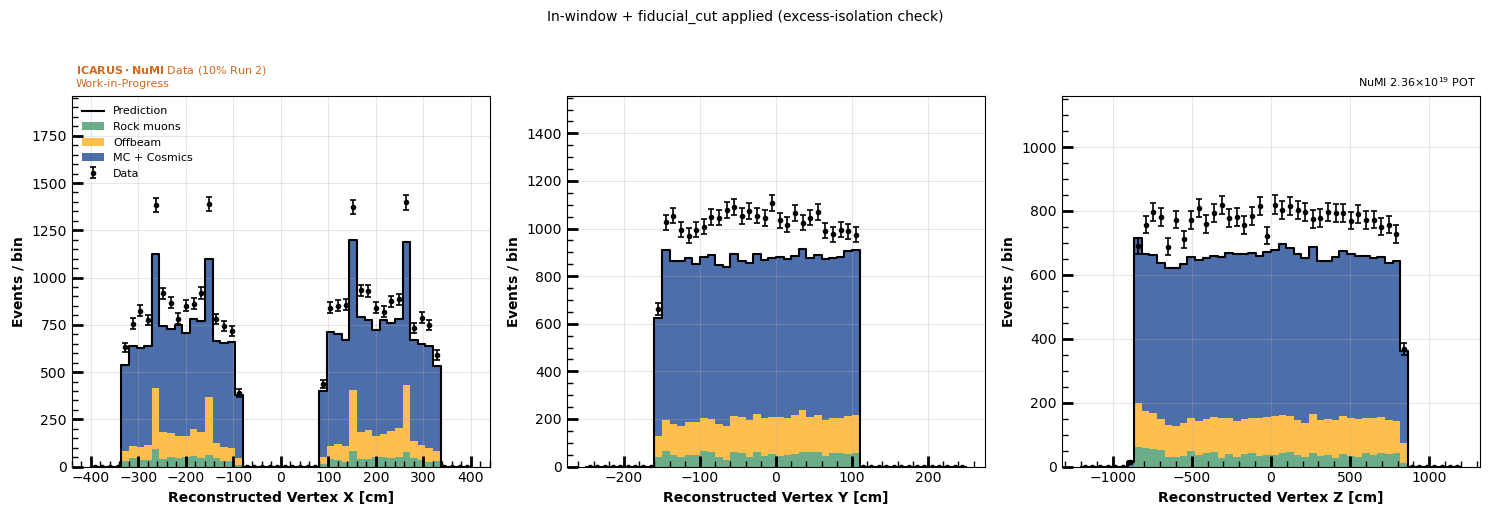


Done.


In [5]:
# ============================================================================
# Vertex X/Y/Z shape check, INSIDE the fiducial volume (in-window + fiducial),
# 3-component stack, three subplots in one row.
#
# WHY THIS CELL: the previous cell showed that fiducial_cut alone reproduces
# the ~17% excess seen on the full `preselection` tree (Stage B data/pred =
# 1.1719 vs the full-tree 1.1710), while in-window ONLY (no fiducial) gives
# good agreement (0.9447). It also showed offbeam's retention under
# fiducial_cut (7.62%) is much lower than onbeam data's (27.64%) -- but
# forcing offbeam to match data's retention overcorrects the ratio to 0.81,
# so it is not simply a flat normalization mismatch. This cell checks
# whether the excess is a SHAPE effect instead: does it concentrate in a
# specific vertex_x/y/z region (e.g. near the 210.215 cm internal-cathode
# exclusion boundary in cuts.h's fiducial_cut), or is it spread uniformly
# across the fiducial volume?
#
# Self-contained: reloads preselection_nocuts fresh (does not depend on the
# previous cell having been run), applies the same in-window filter, then
# ADDITIONALLY applies reco_fiducial == True (this is new relative to the
# earlier zero-cut cell -- that one deliberately did NOT apply fiducial_cut).
#
# Reuses DATA_FILE/ONBEAM_POT/POT_CORRECTION_FACTOR/OUTPUT_DIR/
# ROCK_ANGULAR_VALLEY/compute_ppfx from the trigger-time cell above (run
# that cell first). Local style helpers, same reasoning as the cells above.
# ============================================================================

print("CELL VERSION: fiducial_vertex_shapes_v1_2026-08-22")

import os
import numpy as np
import matplotlib.pyplot as plt
import uproot

def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

TREE_NOCUTS = "preselection_nocuts"

f5 = uproot.open(DATA_FILE)  # reopened for a clean scope

def read_exposure_fv(sample, tree=TREE_NOCUTS):
    pot = lt = None
    if f"events/{sample}/POT" in f5:
        pot = f5[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f5:
        lt = f5[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f5:
        raise KeyError(f"no exposure info for '{sample}' (tree={tree})")
    arrays = f5[key].arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt

print(f"\nReading exposures ({TREE_NOCUTS} tree)...")
_,             onbeam_lt_fv  = read_exposure_fv("onbeam")
_,             offbeam_lt_fv = read_exposure_fv("offbeam")
rock_pot_fv,       _         = read_exposure_fv("rock")
nominal_pot_raw_fv, _        = read_exposure_fv("nominal")

nominal_pot_fv = nominal_pot_raw_fv * POT_CORRECTION_FACTOR
mc_scale_fv      = ONBEAM_POT / nominal_pot_fv
offbeam_scale_fv = onbeam_lt_fv / offbeam_lt_fv
rock_scale_fv    = ONBEAM_POT / rock_pot_fv

_VTX_BR  = ["reco_vertex_x", "reco_vertex_y", "reco_vertex_z",
            "reco_flash_time", "reco_fiducial"]
_MC_BR   = _VTX_BR + ["true_pdg", "true_neutrino_energy"]
_ROCK_BR = _VTX_BR + ["reco_longest_track_start_dir_x",
                      "reco_longest_track_start_dir_y",
                      "reco_longest_track_start_dir_z"]

print(f"\nLoading '{TREE_NOCUTS}' trees (branch-filtered, fiducial included)...")
mc_fv      = f5[f"events/nominal/{TREE_NOCUTS}"].arrays(_MC_BR, library="pd")
rock_fv    = f5[f"events/rock/{TREE_NOCUTS}"].arrays(_ROCK_BR, library="pd")
onbeam_fv  = f5[f"events/onbeam/{TREE_NOCUTS}"].arrays(_VTX_BR, library="pd")
offbeam_fv = f5[f"events/offbeam/{TREE_NOCUTS}"].arrays(_VTX_BR, library="pd")

FLASH_LO, FLASH_HI = 0.0, 9.6
def apply_in_window(df, name):
    ft = df["reco_flash_time"].values
    mask = np.isfinite(ft) & (ft >= FLASH_LO) & (ft <= FLASH_HI)
    n_before = len(df)
    out = df[mask].reset_index(drop=True)
    print(f"  {name:>8}: {n_before} -> {len(out)}  in-window")
    return out

print(f"\nApplying in-beam-window requirement:")
mc_fv      = apply_in_window(mc_fv,      "nominal")
rock_fv    = apply_in_window(rock_fv,    "rock")
onbeam_fv  = apply_in_window(onbeam_fv,  "onbeam")
offbeam_fv = apply_in_window(offbeam_fv, "offbeam")

print(f"\nApplying reco_fiducial == True:")
def apply_fiducial(df, name):
    mask = df["reco_fiducial"].astype(bool).values
    n_before = len(df)
    out = df[mask].reset_index(drop=True)
    print(f"  {name:>8}: {n_before} -> {len(out)}  in fiducial volume")
    return out

mc_fv      = apply_fiducial(mc_fv,      "nominal")
rock_fv    = apply_fiducial(rock_fv,    "rock")
onbeam_fv  = apply_fiducial(onbeam_fv,  "onbeam")
offbeam_fv = apply_fiducial(offbeam_fv, "offbeam")

mc_fv["ppfx_weight"] = compute_ppfx(mc_fv)

_vx = rock_fv["reco_longest_track_start_dir_x"].values
_vy = rock_fv["reco_longest_track_start_dir_y"].values
_vz = rock_fv["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
_cos_theta_y = np.full(len(rock_fv), np.nan)
_cos_theta_y[_valid_dir] = _vy[_valid_dir] / _norm[_valid_dir]
_is_rocklike = _valid_dir & (_cos_theta_y > ROCK_ANGULAR_VALLEY)
n_rock_before_fv = len(rock_fv)
rock_fv = rock_fv[_is_rocklike].reset_index(drop=True)
print(f"\nRock angular (directionality) cut: {n_rock_before_fv} -> {len(rock_fv)} "
      f"({len(rock_fv)/n_rock_before_fv:.1%} kept)")

STACK = [
    ("MC",      "MC + Cosmics", "#003087"),
    ("Rock",    "Rock muons",   "seagreen"),
    ("Offbeam", "Offbeam",      "orange"),
]

FV_SPECS = [
    ("reco_vertex_x", "Reconstructed Vertex X [cm]", np.linspace(-400, 400, 51)),
    ("reco_vertex_y", "Reconstructed Vertex Y [cm]", np.linspace(-250, 250, 51)),
    ("reco_vertex_z", "Reconstructed Vertex Z [cm]", np.linspace(-1200, 1200, 51)),
]

w_mc = mc_fv["ppfx_weight"].values * mc_scale_fv

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (variable, xlabel, bins) in zip(axes, FV_SPECS):
    bins = np.asarray(bins, dtype=float)
    centers = 0.5 * (bins[:-1] + bins[1:])
    width = bins[1:] - bins[:-1]

    mc_h  = np.histogram(mc_fv[variable].values, bins=bins, weights=w_mc)[0]
    rk_h  = np.histogram(rock_fv[variable].values, bins=bins,
                         weights=np.full(len(rock_fv), rock_scale_fv))[0]
    off_h = np.histogram(offbeam_fv[variable].values, bins=bins,
                         weights=np.full(len(offbeam_fv), offbeam_scale_fv))[0]
    dat_h = np.histogram(onbeam_fv[variable].values, bins=bins)[0]
    dat_err = np.sqrt(dat_h)

    comps = {"MC": mc_h, "Rock": rk_h, "Offbeam": off_h}
    pred = sum(comps[k] for k, _, _ in STACK)

    draw_order = ["Rock", "Offbeam", "MC"]
    label_of = {k: lab for k, lab, _ in STACK}
    color_of = {k: col for k, _, col in STACK}
    base = np.zeros(len(bins) - 1)
    for k in draw_order:
        ax.bar(centers, comps[k], width=width, bottom=base, color=color_of[k],
               alpha=0.7, label=label_of[k])
        base = base + comps[k]
    ax.step(np.append(bins[:-1], bins[-1]), np.append(pred, pred[-1]),
            where='post', color='black', linewidth=1.5, label="Prediction")
    ax.errorbar(centers, dat_h, yerr=dat_err, fmt='o', markersize=3,
                markerfacecolor="black", markeredgecolor="black", color="black",
                capsize=2, capthick=1.2, elinewidth=1.2, label="Data", zorder=5)

    ax.set_xlabel(xlabel, fontsize=10, fontweight='bold')
    ax.set_ylabel(r"$\mathbf{Events\ /\ bin}$", fontsize=10, fontfamily="sans-serif")
    ax.grid(True, alpha=0.3)
    apply_tick_style(ax)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)

axes[0].legend(fontsize=8, loc='upper left', framealpha=0.0, edgecolor='none')
add_icarus_label(axes[0])
pot_str_fv = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"
add_pot_label(axes[2], pot_str_fv)

fig.suptitle("In-window + fiducial_cut applied (excess-isolation check)",
             fontsize=10, y=1.02)
fig.tight_layout()

os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "jpeg/fiducial_inwindow_vertex_xyz.jpeg"),
            bbox_inches="tight", dpi=200)
plt.show()
plt.close(fig)

print("\nDone.")


In [6]:
# ============================================================================
# Cumulative cutflow on preselection_nocuts, in the exact order of the final
# selection's cut list:
#   fiducial_cut -> flash_cut -> no_photons -> no_electrons -> single_muon ->
#   no_charged_pions -> !no_protons -> [trigger_emulation_cut + data_quality_cut]
#
# WHY THIS CELL: the previous cell isolated fiducial_cut as the driver of the
# ~17% excess at the preselection stage (Stage B data/pred = 1.1719, matching
# the full preselection-tree result of 1.1710 almost exactly). This cell
# extends that same technique to the FULL final-selection cut list. Every
# reco-level cut in that list already has its own boolean branch on
# preselection_nocuts (fiducial, flash_cut, no_photons, no_electrons,
# single_muon, no_charged_pions, no_protons -- see preselection.toml's
# `branch = [...]` block), computed with the SAME @parameter values used in
# the [parameters] section, so no rebuild is needed for these seven. Applying
# them cumulatively in pandas, in the real cut order, and printing data/pred
# after each one shows exactly which cut (if any, beyond fiducial_cut) moves
# the ratio further.
#
# The last two cuts (trigger_emulation_cut, data_quality_cut) have no branch
# equivalent here -- their inputs (global trigger time, run number) are not
# exposed on this tree. Their COMBINED effect (not individually separable) is
# obtained instead by checking, for survivors of the 7 reco cuts, whether
# their (Run, Subrun, Evt) key is also present in the `trigger_time` tree --
# any event in `trigger_time` passed both cuts; any event missing from it
# failed at least one. Same join technique already used for the PPFX lookup
# in cell 0.
#
# Self-contained: reloads preselection_nocuts and trigger_time fresh. Reuses
# DATA_FILE/ONBEAM_POT/POT_CORRECTION_FACTOR/ROCK_ANGULAR_VALLEY/compute_ppfx
# from the trigger-time cell above (run that cell first). No plots -- numbers
# only, this is a diagnostic cell.
# ============================================================================

print("CELL VERSION: cumulative_cutflow_v1_2026-08-22")

import numpy as np
import uproot

TREE_NOCUTS = "preselection_nocuts"
TREE_TRIG   = "trigger_time"

f6 = uproot.open(DATA_FILE)  # reopened for a clean scope

def read_exposure_cf(sample, tree=TREE_NOCUTS):
    pot = lt = None
    if f"events/{sample}/POT" in f6:
        pot = f6[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f6:
        lt = f6[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f6:
        raise KeyError(f"no exposure info for '{sample}' (tree={tree})")
    arrays = f6[key].arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt

print(f"\nReading exposures ({TREE_NOCUTS} tree)...")
_,             onbeam_lt_cf  = read_exposure_cf("onbeam")
_,             offbeam_lt_cf = read_exposure_cf("offbeam")
rock_pot_cf,       _         = read_exposure_cf("rock")
nominal_pot_raw_cf, _        = read_exposure_cf("nominal")

nominal_pot_cf = nominal_pot_raw_cf * POT_CORRECTION_FACTOR
mc_scale_cf      = ONBEAM_POT / nominal_pot_cf
offbeam_scale_cf = onbeam_lt_cf / offbeam_lt_cf
rock_scale_cf    = ONBEAM_POT / rock_pot_cf

_CUT_BR  = ["reco_fiducial", "reco_flash_cut", "reco_no_photons",
            "reco_no_electrons", "reco_single_muon", "reco_no_charged_pions",
            "reco_no_protons", "Run", "Subrun", "Evt"]
_MC_BR   = _CUT_BR + ["true_pdg", "true_neutrino_energy"]
_ROCK_BR = _CUT_BR + ["reco_longest_track_start_dir_x",
                      "reco_longest_track_start_dir_y",
                      "reco_longest_track_start_dir_z"]

print(f"\nLoading '{TREE_NOCUTS}' trees (branch-filtered, all 7 reco-cut branches)...")
mc_cf      = f6[f"events/nominal/{TREE_NOCUTS}"].arrays(_MC_BR, library="pd")
rock_cf    = f6[f"events/rock/{TREE_NOCUTS}"].arrays(_ROCK_BR, library="pd")
onbeam_cf  = f6[f"events/onbeam/{TREE_NOCUTS}"].arrays(_CUT_BR, library="pd")
offbeam_cf = f6[f"events/offbeam/{TREE_NOCUTS}"].arrays(_CUT_BR, library="pd")

for name, df in (("nominal", mc_cf), ("rock", rock_cf), ("onbeam", onbeam_cf),
                 ("offbeam", offbeam_cf)):
    print(f"  {name:>8}: {len(df)} rows")

mc_cf["ppfx_weight"] = compute_ppfx(mc_cf)
w_mc_full = mc_cf["ppfx_weight"].values * mc_scale_cf

# ---- rock angular (directionality) cut -- sample definition, applied once
#      up front, same as every other cell this session (not part of the
#      final-selection cut list itself) ----
_vx = rock_cf["reco_longest_track_start_dir_x"].values
_vy = rock_cf["reco_longest_track_start_dir_y"].values
_vz = rock_cf["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
_cos_theta_y = np.full(len(rock_cf), np.nan)
_cos_theta_y[_valid_dir] = _vy[_valid_dir] / _norm[_valid_dir]
_is_rocklike = _valid_dir & (_cos_theta_y > ROCK_ANGULAR_VALLEY)
n_rock_before_cf = len(rock_cf)
rock_cf = rock_cf[_is_rocklike].reset_index(drop=True)
print(f"\nRock angular (directionality) cut (sample definition, not a "
      f"final-selection cut): {n_rock_before_cf} -> {len(rock_cf)} "
      f"({len(rock_cf)/n_rock_before_cf:.1%} kept)")

STEPS = [
    ("fiducial_cut",      "reco_fiducial"),
    ("flash_cut",         "reco_flash_cut"),
    ("no_photons",        "reco_no_photons"),
    ("no_electrons",      "reco_no_electrons"),
    ("single_muon",       "reco_single_muon"),
    ("no_charged_pions",  "reco_no_charged_pions"),
    ("!no_protons",       None),  # handled specially -- negated
]

def cutbool(df, col):
    return df[col].astype(bool).values

mask_mc      = np.ones(len(mc_cf),      dtype=bool)
mask_rock    = np.ones(len(rock_cf),    dtype=bool)
mask_onbeam  = np.ones(len(onbeam_cf),  dtype=bool)
mask_offbeam = np.ones(len(offbeam_cf), dtype=bool)

print(f"\n{'Step':<20}{'MC':>12}{'Rock':>12}{'Offbeam':>12}{'PRED':>12}{'DATA':>10}{'data/pred':>12}")
print("-" * 90)

def report(step_name):
    mc_tot   = w_mc_full[mask_mc].sum()
    rock_tot = mask_rock.sum() * rock_scale_cf
    off_tot  = mask_offbeam.sum() * offbeam_scale_cf
    pred = mc_tot + rock_tot + off_tot
    data = int(mask_onbeam.sum())
    ratio = data / pred if pred > 0 else float("nan")
    print(f"{step_name:<20}{mc_tot:12.1f}{rock_tot:12.1f}{off_tot:12.1f}"
          f"{pred:12.1f}{data:10d}{ratio:12.4f}")
    return ratio

report("(no cuts)")

for name, col in STEPS:
    if col is not None:
        mask_mc      &= cutbool(mc_cf,      col)
        mask_rock    &= cutbool(rock_cf,    col)
        mask_onbeam  &= cutbool(onbeam_cf,  col)
        mask_offbeam &= cutbool(offbeam_cf, col)
    else:
        # !no_protons -- require at least one proton, i.e. reco_no_protons == False
        mask_mc      &= ~cutbool(mc_cf,      "reco_no_protons")
        mask_rock    &= ~cutbool(rock_cf,    "reco_no_protons")
        mask_onbeam  &= ~cutbool(onbeam_cf,  "reco_no_protons")
        mask_offbeam &= ~cutbool(offbeam_cf, "reco_no_protons")
    report(name)

# ---- combined trigger_emulation_cut + data_quality_cut, via Run/Subrun/Evt
#      join against the trigger_time tree (which already has both baked in) --
print(f"\nLoading '{TREE_TRIG}' (Run/Subrun/Evt only) for the trigger/DQ join...")

def trig_keys(sample):
    arr = f6[f"events/{sample}/{TREE_TRIG}"].arrays(["Run", "Subrun", "Evt"], library="pd")
    return set(map(tuple, arr.drop_duplicates().values))

trig_keys_mc      = trig_keys("nominal")
trig_keys_rock    = trig_keys("rock")
trig_keys_onbeam  = trig_keys("onbeam")
trig_keys_offbeam = trig_keys("offbeam")

def in_trig(df, keyset):
    keys = list(map(tuple, df[["Run", "Subrun", "Evt"]].values))
    return np.array([k in keyset for k in keys], dtype=bool)

mask_mc      &= in_trig(mc_cf,      trig_keys_mc)
mask_rock    &= in_trig(rock_cf,    trig_keys_rock)
mask_onbeam  &= in_trig(onbeam_cf,  trig_keys_onbeam)
mask_offbeam &= in_trig(offbeam_cf, trig_keys_offbeam)

report("+trigger+DQ")

print("\nDone.")


CELL VERSION: cumulative_cutflow_v1_2026-08-22

Reading exposures (preselection_nocuts tree)...

Loading 'preselection_nocuts' trees (branch-filtered, all 7 reco-cut branches)...
   nominal: 55088959 rows
      rock: 7808842 rows
    onbeam: 3202605 rows
   offbeam: 19470760 rows

Rock angular (directionality) cut (sample definition, not a final-selection cut): 7808842 -> 2097982 (26.9% kept)

Step                          MC        Rock     Offbeam        PRED      DATA   data/pred
------------------------------------------------------------------------------------------
(no cuts)              1810117.4   2902594.1   1855475.8   6568187.3   3202605      0.4876
fiducial_cut            654304.1   1230548.6    654766.5   2539619.2   1163274      0.4581
flash_cut                18065.2      1391.8      3995.6     23452.7     27483      1.1719
no_photons               14401.8      1286.7      3748.8     19437.3     22885      1.1774
no_electrons             13571.2      1214.7      3549.9 

In [7]:
# ============================================================================
# single_muon isolation: why does the fiducial+flash+no_photons+no_electrons
# -> +single_muon step move data/pred from 1.1866 to 1.3351 (the largest
# single jump in the cumulative cutflow)?
#
# single_muon requires EXACTLY ONE primary muon-candidate above threshold
# (cuts.h::single_particle_multiplicity: count == 1, not count >= 1) --
# see the muon_multiplicity() variable in variables.h, which is the same
# count with the same @muon_threshold parameter, already a branch on
# preselection_nocuts. Failing single_muon can happen two structurally
# different ways: count == 0 (no reconstructed muon-like primary at all --
# a reconstruction-efficiency failure) or count >= 2 (an extra spurious
# muon-like primary -- a track-splitting / misclassification failure). This
# cell splits the fiducial+flash+no_photons+no_electrons sample by
# muon_multiplicity bin (0, 1, 2+) and reports data/pred separately for
# each bin, to see which bin the excess concentrates in rather than
# guessing.
#
# Self-contained: reloads preselection_nocuts fresh. Reuses DATA_FILE/
# ONBEAM_POT/POT_CORRECTION_FACTOR/ROCK_ANGULAR_VALLEY/compute_ppfx from the
# trigger-time cell above (run that cell first). No plots -- numbers only.
# ============================================================================

print("CELL VERSION: single_muon_isolation_v1_2026-08-22")

import numpy as np
import uproot

TREE_NOCUTS = "preselection_nocuts"

f7 = uproot.open(DATA_FILE)  # reopened for a clean scope

def read_exposure_sm(sample, tree=TREE_NOCUTS):
    pot = lt = None
    if f"events/{sample}/POT" in f7:
        pot = f7[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f7:
        lt = f7[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f7:
        raise KeyError(f"no exposure info for '{sample}' (tree={tree})")
    arrays = f7[key].arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt

print(f"\nReading exposures ({TREE_NOCUTS} tree)...")
_,             onbeam_lt_sm  = read_exposure_sm("onbeam")
_,             offbeam_lt_sm = read_exposure_sm("offbeam")
rock_pot_sm,       _         = read_exposure_sm("rock")
nominal_pot_raw_sm, _        = read_exposure_sm("nominal")

nominal_pot_sm = nominal_pot_raw_sm * POT_CORRECTION_FACTOR
mc_scale_sm      = ONBEAM_POT / nominal_pot_sm
offbeam_scale_sm = onbeam_lt_sm / offbeam_lt_sm
rock_scale_sm    = ONBEAM_POT / rock_pot_sm

_CUT_BR  = ["reco_fiducial", "reco_flash_cut", "reco_no_photons",
            "reco_no_electrons", "reco_muon_multiplicity"]
_MC_BR   = _CUT_BR + ["true_pdg", "true_neutrino_energy"]
_ROCK_BR = _CUT_BR + ["reco_longest_track_start_dir_x",
                      "reco_longest_track_start_dir_y",
                      "reco_longest_track_start_dir_z"]

print(f"\nLoading '{TREE_NOCUTS}' trees (branch-filtered)...")
mc_sm      = f7[f"events/nominal/{TREE_NOCUTS}"].arrays(_MC_BR, library="pd")
rock_sm    = f7[f"events/rock/{TREE_NOCUTS}"].arrays(_ROCK_BR, library="pd")
onbeam_sm  = f7[f"events/onbeam/{TREE_NOCUTS}"].arrays(_CUT_BR, library="pd")
offbeam_sm = f7[f"events/offbeam/{TREE_NOCUTS}"].arrays(_CUT_BR, library="pd")

mc_sm["ppfx_weight"] = compute_ppfx(mc_sm)

# ---- rock angular cut, sample definition ----
_vx = rock_sm["reco_longest_track_start_dir_x"].values
_vy = rock_sm["reco_longest_track_start_dir_y"].values
_vz = rock_sm["reco_longest_track_start_dir_z"].values
_norm = np.sqrt(_vx**2 + _vy**2 + _vz**2)
_valid_dir = np.isfinite(_norm) & (_norm > 0)
_cos_theta_y = np.full(len(rock_sm), np.nan)
_cos_theta_y[_valid_dir] = _vy[_valid_dir] / _norm[_valid_dir]
_is_rocklike = _valid_dir & (_cos_theta_y > ROCK_ANGULAR_VALLEY)
rock_sm = rock_sm[_is_rocklike].reset_index(drop=True)

# ---- apply fiducial + flash_cut + no_photons + no_electrons (the state
#      immediately BEFORE single_muon in the cumulative cutflow) ----
def presel4(df):
    mask = (df["reco_fiducial"].astype(bool).values
            & df["reco_flash_cut"].astype(bool).values
            & df["reco_no_photons"].astype(bool).values
            & df["reco_no_electrons"].astype(bool).values)
    return df[mask].reset_index(drop=True)

mc_sm      = presel4(mc_sm)
rock_sm    = presel4(rock_sm)
onbeam_sm  = presel4(onbeam_sm)
offbeam_sm = presel4(offbeam_sm)

for name, df in (("nominal", mc_sm), ("rock", rock_sm), ("onbeam", onbeam_sm),
                 ("offbeam", offbeam_sm)):
    print(f"  {name:>8}: {len(df)} rows after fiducial+flash+no_photons+no_electrons")

w_mc = mc_sm["ppfx_weight"].values * mc_scale_sm

print(f"\n{'muon_mult':<12}{'MC frac':>10}{'Rock frac':>10}{'Offbeam frac':>14}{'Data frac':>12}")
mult_bins = {"0": lambda x: x == 0, "1": lambda x: x == 1, "2+": lambda x: x >= 2}
mc_mult      = mc_sm["reco_muon_multiplicity"].values
rock_mult    = rock_sm["reco_muon_multiplicity"].values
onbeam_mult  = onbeam_sm["reco_muon_multiplicity"].values
offbeam_mult = offbeam_sm["reco_muon_multiplicity"].values

mc_total_w      = w_mc.sum()
rock_total_w    = len(rock_sm) * rock_scale_sm
offbeam_total_w = len(offbeam_sm) * offbeam_scale_sm
data_total      = len(onbeam_sm)

for label, sel in mult_bins.items():
    mc_f      = w_mc[sel(mc_mult)].sum() / mc_total_w
    rock_f    = sel(rock_mult).sum() * rock_scale_sm / rock_total_w
    off_f     = sel(offbeam_mult).sum() * offbeam_scale_sm / offbeam_total_w
    data_f    = sel(onbeam_mult).sum() / data_total
    print(f"{label:<12}{mc_f:10.3f}{rock_f:10.3f}{off_f:14.3f}{data_f:12.3f}")

print(f"\n{'muon_mult':<12}{'MC':>12}{'Rock':>12}{'Offbeam':>12}{'PRED':>12}{'DATA':>10}{'data/pred':>12}")
print("-" * 82)
for label, sel in mult_bins.items():
    mc_e   = w_mc[sel(mc_mult)].sum()
    rock_e = sel(rock_mult).sum() * rock_scale_sm
    off_e  = sel(offbeam_mult).sum() * offbeam_scale_sm
    pred   = mc_e + rock_e + off_e
    data   = int(sel(onbeam_mult).sum())
    ratio  = data / pred if pred > 0 else float("nan")
    print(f"{label:<12}{mc_e:12.1f}{rock_e:12.1f}{off_e:12.1f}{pred:12.1f}{data:10d}{ratio:12.4f}")

print("\nDone.")


CELL VERSION: single_muon_isolation_v1_2026-08-22

Reading exposures (preselection_nocuts tree)...

Loading 'preselection_nocuts' trees (branch-filtered)...
   nominal: 430663 rows after fiducial+flash+no_photons+no_electrons
      rock: 878 rows after fiducial+flash+no_photons+no_electrons
    onbeam: 21758 rows after fiducial+flash+no_photons+no_electrons
   offbeam: 37252 rows after fiducial+flash+no_photons+no_electrons

muon_mult      MC frac Rock frac  Offbeam frac   Data frac
0                0.393     0.273         0.184       0.269
1                0.597     0.719         0.804       0.726
2+               0.010     0.008         0.012       0.005

muon_mult             MC        Rock     Offbeam        PRED      DATA   data/pred
----------------------------------------------------------------------------------
0                 5339.1       332.0       652.1      6323.2      5848      0.9248
1                 8099.3       873.0      2855.7     11828.0     15791      1.3351
2+

In [10]:
# ============================================================================
# Does nominal MC's raw (uncut) fiducial-true bin have a different truth
# composition than its fiducial-false bin? This tests the composition
# hypothesis directly instead of assuming it: if nominal's higher raw
# fiducial fraction (50%, vs ~36% for rock/onbeam/offbeam) comes from
# genuinely containing more beam-neutrino truth, the fiducial-true bin
# should be enriched in the beam-neutrino categories (0-8) and the
# fiducial-false bin should be dominated by category 9 (Cosmic). If the
# category mix looks similar in both bins, that explanation is wrong and
# nominal's higher raw fiducial fraction needs a different explanation.
#
# `category` (branch, type="true") is a real truth-level classification
# built from the `[[category]]` blocks in preselection.toml -- NOT the
# dummy GUNDAM `cut_type` placeholder found earlier in event_variables.h.
# The enumeration (from the toml comments):
#   0: Signal, QE                5: Uncontained muon, fiducial
#   1: Signal, MEC (2p2h)        6: Uncontained muon
#   2: Signal, other             7: Neutrino, CC
#   3: OOFV (signal-like)        8: Neutrino, NC
#   4: numuCC Np1pi+-            9: Cosmic
#
# Self-contained, nominal only (this is a truth-level question, so only MC
# has a meaningful `category` -- data has no truth information). Reuses
# DATA_FILE from the trigger-time cell above (run that cell first). No
# plots -- numbers only.
# ============================================================================

print("CELL VERSION: nominal_category_by_fiducial_v1_2026-08-22")

import numpy as np
import uproot

TREE_NOCUTS = "preselection_nocuts"

f8 = uproot.open(DATA_FILE)  # reopened for a clean scope

_BR = ["reco_fiducial", "true_category"]
print(f"\nLoading events/nominal/{TREE_NOCUTS} (reco_fiducial, category)...")
mc_cat = f8[f"events/nominal/{TREE_NOCUTS}"].arrays(_BR, library="pd")
print(f"  nominal: {len(mc_cat)} rows")

CAT_LABELS = {
    0: "Signal QE", 1: "Signal MEC", 2: "Signal other", 3: "OOFV",
    4: "numuCC Np1pi+-", 5: "Uncontained mu, fiducial",
    6: "Uncontained mu", 7: "Neutrino CC", 8: "Neutrino NC", 9: "Cosmic",
}

fid = mc_cat["reco_fiducial"].astype(bool).values
cat = mc_cat["true_category"].values

n_fid_true  = fid.sum()
n_fid_false = (~fid).sum()
print(f"\nraw fiducial split: True={n_fid_true} ({n_fid_true/len(fid):.4f}), "
      f"False={n_fid_false} ({n_fid_false/len(fid):.4f})")

print(f"\n{'category':<28}{'frac(fid=True)':>16}{'frac(fid=False)':>18}")
print("-" * 62)
cats_present = sorted(set(np.unique(cat.astype(int))))
for c in cats_present:
    label = CAT_LABELS.get(c, f"unknown({c})")
    f_true  = (cat[fid] == c).sum() / n_fid_true if n_fid_true > 0 else float("nan")
    f_false = (cat[~fid] == c).sum() / n_fid_false if n_fid_false > 0 else float("nan")
    print(f"{label:<28}{f_true:16.4f}{f_false:18.4f}")

# ---- grouped summary: beam-neutrino-like (0-8) vs Cosmic (9) ----
is_beam = cat < 9
beam_frac_true  = (is_beam[fid]).sum()  / n_fid_true  if n_fid_true  > 0 else float("nan")
beam_frac_false = (is_beam[~fid]).sum() / n_fid_false if n_fid_false > 0 else float("nan")
print(f"\n{'grouped':<28}{'frac(fid=True)':>16}{'frac(fid=False)':>18}")
print("-" * 62)
print(f"{'Beam-neutrino (cat 0-8)':<28}{beam_frac_true:16.4f}{beam_frac_false:18.4f}")
print(f"{'Cosmic (cat 9)':<28}{1-beam_frac_true:16.4f}{1-beam_frac_false:18.4f}")

print("\nDone.")


CELL VERSION: nominal_category_by_fiducial_v1_2026-08-22

Loading events/nominal/preselection_nocuts (reco_fiducial, category)...
  nominal: 55088959 rows

raw fiducial split: True=19922850 (0.3616), False=35166109 (0.6384)

category                      frac(fid=True)   frac(fid=False)
--------------------------------------------------------------


/var/folders/hn/gg8vh0yd4j1382jb74b5wr780000gn/T/ipykernel_70928/2554412397.py:58: RuntimeWarning: invalid value encountered in cast
  cats_present = sorted(set(np.unique(cat.astype(int))))


Signal QE                             0.0040            0.0003
Signal MEC                            0.0015            0.0001
Signal other                          0.0013            0.0001
OOFV                                  0.0005            0.0021
numuCC Np1pi+-                        0.0065            0.0027
Uncontained mu, fiducial              0.0070            0.0008
Uncontained mu                        0.0023            0.0070
Neutrino CC                           0.0045            0.0029
Neutrino NC                           0.0095            0.0035
Cosmic                                0.9358            0.9584

grouped                       frac(fid=True)   frac(fid=False)
--------------------------------------------------------------
Beam-neutrino (cat 0-8)               0.0371            0.0195
Cosmic (cat 9)                        0.9629            0.9805

Done.


In [11]:
# ============================================================================
# ROOT cycle check.
#
# WHY THIS CELL: your TBrowser draw of `reco_fiducial` alone shows 33,554,432
# entries and mean 0.3616 for events/nominal/preselection_nocuts -- but the
# object path shown in the plot is explicitly "preselection_nocuts;1" (note
# the ";1"). Every uproot read in this notebook so far (cells 2, 4, 5, 6, 7,
# 8) opened events/nominal/preselection_nocuts WITHOUT a cycle number and
# consistently got 55,088,959 rows for the same tree/sample. Those two
# numbers don't match (33,554,432 != 55,088,959), and ";1" explicitly pins
# ROOT to the FIRST cycle written under that name.
#
# ROOT TTrees get a new "cycle" (";1", ";2", ...) every time an object with
# the same name is written to the same TDirectory without deleting the old
# one first -- a common artifact of re-running a production step and
# appending to an existing ROOT file rather than recreating it fresh. Tools
# differ in which cycle they resolve to by default: uproot's bare-name
# lookup (what every cell in this notebook has used) typically resolves to
# the HIGHEST cycle number, while an explicit ";1" reference in a TBrowser
# path pins the OLDEST one. If preselection.root has multiple cycles of
# preselection_nocuts (and possibly other trees) sitting in it, different
# tools -- or even the same tool used two different ways -- can silently
# read two different versions of "the same" tree.
#
# This cell lists every cycle present for the trees this notebook has been
# reading, for all four samples, with each cycle's entry count, so we know
# definitively whether stale cycles exist and which one every prior cell in
# this notebook actually read.
# ============================================================================

print("CELL VERSION: root_cycle_check_v1_2026-08-22")

import uproot

f9 = uproot.open(DATA_FILE)

TREES = ["preselection", "preselection_nocuts", "trigger_time"]
SAMPLES = ["nominal", "rock", "onbeam", "offbeam"]

all_keys = f9.keys(recursive=True, cycle=True)  # e.g. "events/nominal/preselection_nocuts;2"

print(f"\nTotal keys in file: {len(all_keys)}")

for sample in SAMPLES:
    print(f"\n=== events/{sample} ===")
    for tree in TREES:
        prefix = f"events/{sample}/{tree};"
        matches = sorted(
            [k for k in all_keys if k.startswith(prefix)],
            key=lambda k: int(k.split(";")[-1])
        )
        if not matches:
            print(f"  {tree:<20} -- no cycles found")
            continue
        for k in matches:
            n = f9[k].num_entries
            print(f"  {k:<45} entries={n}")
        # what does a BARE (no-cycle) lookup resolve to?
        bare = f9[f"events/{sample}/{tree}"]
        highest_cycle = matches[-1].split(";")[-1]
        print(f"    -> bare lookup 'events/{sample}/{tree}' gives entries="
              f"{bare.num_entries}  (highest cycle available: ;{highest_cycle})")

print("\nDone.")


CELL VERSION: root_cycle_check_v1_2026-08-22

Total keys in file: 37

=== events/nominal ===
  events/nominal/preselection;1                 entries=19922850
    -> bare lookup 'events/nominal/preselection' gives entries=19922850  (highest cycle available: ;1)
  events/nominal/preselection_nocuts;1          entries=55088959
    -> bare lookup 'events/nominal/preselection_nocuts' gives entries=55088959  (highest cycle available: ;1)
  events/nominal/trigger_time;1                 entries=1501200
    -> bare lookup 'events/nominal/trigger_time' gives entries=1501200  (highest cycle available: ;1)

=== events/rock ===
  events/rock/preselection;1                    entries=2785031
    -> bare lookup 'events/rock/preselection' gives entries=2785031  (highest cycle available: ;1)
  events/rock/preselection_nocuts;1             entries=7808842
    -> bare lookup 'events/rock/preselection_nocuts' gives entries=7808842  (highest cycle available: ;1)
  events/rock/trigger_time;1                